# TikTok Video Engagement Prediction

## Competition Objective

The goal of this competition is to predict the cumulative number of views
a TikTok video will receive by Day 30, using only information available
during the first five days after publication.

The available data includes:

- Video metadata
- Creator statistics
- Daily engagement metrics from Days 0–5

The competition metric is Root Mean Squared Error (RMSE), where lower
values indicate better predictive performance.

Because the target is highly skewed, the analysis focuses on understanding
early engagement patterns, creator characteristics, and the distribution
of Day-30 views before building predictive models.

## 1. Setup

We first import the libraries required for data loading, exploratory
analysis, feature engineering, and later modeling.

The initial notebook focuses on understanding and preparing the data.
Model comparison and hyperparameter experiments are handled separately.

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

The competition data is provided across several tables:

- Video-level metadata
- Daily engagement records
- Daily creator statistics
- Test videos
- Sample submission format

We load the original tables first and inspect their structure before
performing any transformations.

In [47]:
DATA_RAW = Path('../data/raw')

train = pd.read_csv(DATA_RAW / 'train_videos.csv')
test = pd.read_csv(DATA_RAW / 'test_videos.csv')
engagement = pd.read_csv(DATA_RAW / 'engagement_daily.csv')
creators = pd.read_csv(DATA_RAW / 'creators_daily.csv')
sample_sub = pd.read_csv(DATA_RAW / 'sample_submission.csv')

print(f"Train shape:      {train.shape}")
print(f"Test shape:       {test.shape}")
print(f"Engagement shape: {engagement.shape}")
print(f"Creators shape:   {creators.shape}")
print(f"Sample sub shape: {sample_sub.shape}")

Train shape:      (12000, 27)
Test shape:       (3001, 26)
Engagement shape: (79489, 10)
Creators shape:   (252166, 7)
Sample sub shape: (3001, 2)


### Initial Observation

The training set contains 12,000 videos, while the competition test set
contains 3,001 videos.

Engagement data is stored at the video-day level, while creator statistics
are stored at the creator-day level. Therefore, both tables require
aggregation or temporal alignment before they can be used as video-level
features.

## 3. Initial Data Inspection

We inspect the columns, data types, missing values, and basic structure
of each dataset before feature engineering.

This step helps identify missing fields and differences between the
training and test tables.

In [3]:
# ============================================
# Quick Look at Each Dataset
# ============================================
print("=" * 60)
print("TRAIN VIDEOS")
print("=" * 60)
display(train.head())
print(f"\nColumns: {list(train.columns)}")

print("\n" + "=" * 60)
print("TEST VIDEOS")
print("=" * 60)
display(test.head())
print(f"\nColumns: {list(test.columns)}")

print("\n" + "=" * 60)
print("ENGAGEMENT DAILY")
print("=" * 60)
display(engagement.head())
print(f"\nColumns: {list(engagement.columns)}")

print("\n" + "=" * 60)
print("CREATORS DAILY")
print("=" * 60)
display(creators.head())
print(f"\nColumns: {list(creators.columns)}")

TRAIN VIDEOS


,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,music_selected_from,music_author,music_owner_id,music_id,word_count,emoji_count,question_count,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear,target_day30_views
0,7389777708642798891,6823500943611528198,2024-07-09 18:11:50,2024-07-09,61.230,540p,en,1,0.0,0,original,n0stalgiac,6.823501e+18,7.389778e+18,207.0,0.0,1.0,4.0,6.532745,Lifestyle,0.003960,0.790962,0.017963,0.002873,0.004761,0.001092,1371
1,7414315783221693739,6851716737763886085,2024-09-13 21:12:02,2024-09-13,58.095,540p,en,1,0.0,0,shoot_page_recommend_favourite,Grey rose,1.548431e+17,6.601516e+18,171.0,0.0,2.0,6.0,4.148378,Beauty_Fashion,0.004058,0.767556,0.003882,0.012160,0.019463,0.001298,1184
2,7408397785503943942,6809119722295968773,2024-08-28 22:27:16,2024-08-28,7.431,720p,en,1,0.0,0,edit_page_recommend,IG: paulofadventures,7.159158e+18,7.327611e+18,43.0,1.0,0.0,4.0,0.000000,Life_hacks_Personal_growth,0.003275,0.849156,0.003241,0.007868,0.005667,0.003849,638
3,7406460852611681567,6790225026127627269,2024-08-23 17:11:01,2024-08-23,15.046,540p,un,0,0.0,0,shoot_page_recommend,Mystikal,NaN,6.701930e+18,0.0,0.0,0.0,0.0,0.000000,Beauty_Fashion,0.004971,0.612373,0.006764,0.010911,0.066338,0.001878,312
4,7428770082219756831,2033984,2024-10-22 20:02:15,2024-10-22,7.895,540p,en,1,0.0,0,single_song,THUNDER,7.257083e+18,7.402633e+18,NaN,NaN,NaN,NaN,NaN,Beauty_Fashion,0.022163,0.006064,0.008672,0.041306,0.474281,0.022709,180



Columns: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear', 'target_day30_views']

TEST VIDEOS


,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,music_selected_from,music_author,music_owner_id,music_id,word_count,emoji_count,question_count,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear
0,7400582591771938090,6986770031481095173,2024-08-07 21:00:13,2024-08-07,10.100,540p,un,0,0.0,0,duet,Esbmojo7,7.006519e+18,7.398169e+18,2.0,0.0,0.0,2.0,3.564356,Life_hacks_Personal_growth,0.002676,0.938924,0.005082,0.002898,0.009154,0.000414
1,7403167206978374958,6761640179813254150,2024-08-14 20:09:53,2024-08-14,13.815,540p,un,0,1.0,0,single_song,Surf Curse,NaN,6.982680e+18,4.0,0.0,0.0,5.0,0.000000,Dance_Music,0.003034,0.840657,0.005514,0.035231,0.010021,0.000603
2,7435124823820356906,6926128790248080390,2024-11-08 22:01:44,2024-11-08,10.600,540p,un,0,0.0,0,edit_page_recommend,︎︎,7.357672e+18,7.383705e+18,NaN,NaN,NaN,NaN,NaN,Life_hacks_Personal_growth,0.013941,0.821651,0.003380,0.018616,0.032773,0.000685
3,7409800970143714606,6930420307368199173,2024-09-01 17:12:16,2024-09-01,38.289,540p,en,1,0.0,0,original,Superman,6.930420e+18,7.409801e+18,96.0,1.0,0.0,39.0,3.708637,Lifestyle,0.002326,0.958039,0.002441,0.003065,0.005616,0.000298
4,7410935177553333550,6880023927025468421,2024-09-04 18:33:33,2024-09-04,14.883,540p,en,1,0.0,0,single_song,DJ Horizon,6.792172e+18,7.028820e+18,2.0,0.0,0.0,6.0,5.240879,Beauty_Fashion,0.003002,0.906478,0.004138,0.002237,0.003371,0.001028



Columns: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']

ENGAGEMENT DAILY


,video_id,date,days_since_post,play_count,like_count,comment_count,share_count,collect_count,download_count,whatsapp_share_count
0,7384086821132717358,2024-06-24,0,105696,6249,23,1113,1737,59,5
1,7384086821132717358,2024-06-25,1,330084,25291,71,3689,6421,214,25
2,7384086821132717358,2024-06-26,2,390753,32925,93,4476,8082,272,30
3,7384086821132717358,2024-06-27,3,464862,45741,137,5756,10699,358,33
4,7384086821132717358,2024-06-28,4,475386,46896,143,5907,10926,366,33



Columns: ['video_id', 'date', 'days_since_post', 'play_count', 'like_count', 'comment_count', 'share_count', 'collect_count', 'download_count', 'whatsapp_share_count']

CREATORS DAILY


,author_id,date,follower_count,following_count,total_favorited,video_count,enterprise_verified
0,10245051,2024-06-27,1704.0,1039.0,75987,83.0,NaN
1,10245051,2024-06-28,1704.0,1039.0,76018,83.0,NaN
2,10245051,2024-06-29,1704.0,1039.0,76024,83.0,NaN
3,10245051,2024-06-30,1704.0,1039.0,76025,83.0,NaN
4,10245051,2024-07-01,1704.0,1039.0,76029,83.0,NaN



Columns: ['author_id', 'date', 'follower_count', 'following_count', 'total_favorited', 'video_count', 'enterprise_verified']


In [4]:
# ============================================
# Data Info
# ============================================
for name, df in [('train', train), ('test', test), 
                 ('engagement', engagement), ('creators', creators)]:
    print(f"\n{'=' * 60}")
    print(f"{name.upper()}")
    print(f"{'=' * 60}")
    print(f"Shape: {df.shape}")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Dtypes:\n{df.dtypes}")


TRAIN
Shape: (12000, 27)
Missing values:
music_selected_from     121
music_author             21
music_owner_id         2972
music_id                  1
word_count             4047
emoji_count            4047
question_count         4047
hashtag_count          4047
speaking_rate          4047
anger                    42
joy                      42
surprise                 42
sadness                  42
disgust                  42
fear                     42
dtype: int64
Dtypes:
video_id                 int64
author_id                int64
create_time                str
create_date                str
duration               float64
ratio                      str
desc_language              str
is_english               int64
created_by_ai          float64
is_ads                   int64
music_selected_from        str
music_author               str
music_owner_id         float64
music_id               float64
word_count             float64
emoji_count            float64
question_count       

### Key Data-Quality Findings

Several video-level features contain substantial missingness, especially
the text-related features such as `word_count`, `emoji_count`,
`question_count`, `hashtag_count`, and `speaking_rate`.

The creator field `enterprise_verified` contains no non-null values in
the provided creator table, so it does not provide usable information
and should not be treated as a predictive feature.

Missing values will be handled during the modeling pipeline rather than
being removed from the dataset.

TARGET: target_day30_views

Basic Statistics:
count    1.200000e+04
mean     2.922860e+04
std      2.752131e+05
min      0.000000e+00
25%      3.440000e+02
50%      6.680000e+02
75%      3.016500e+03
max      1.631055e+07
Name: target_day30_views, dtype: float64

Skewness: 29.133
Kurtosis: 1268.776


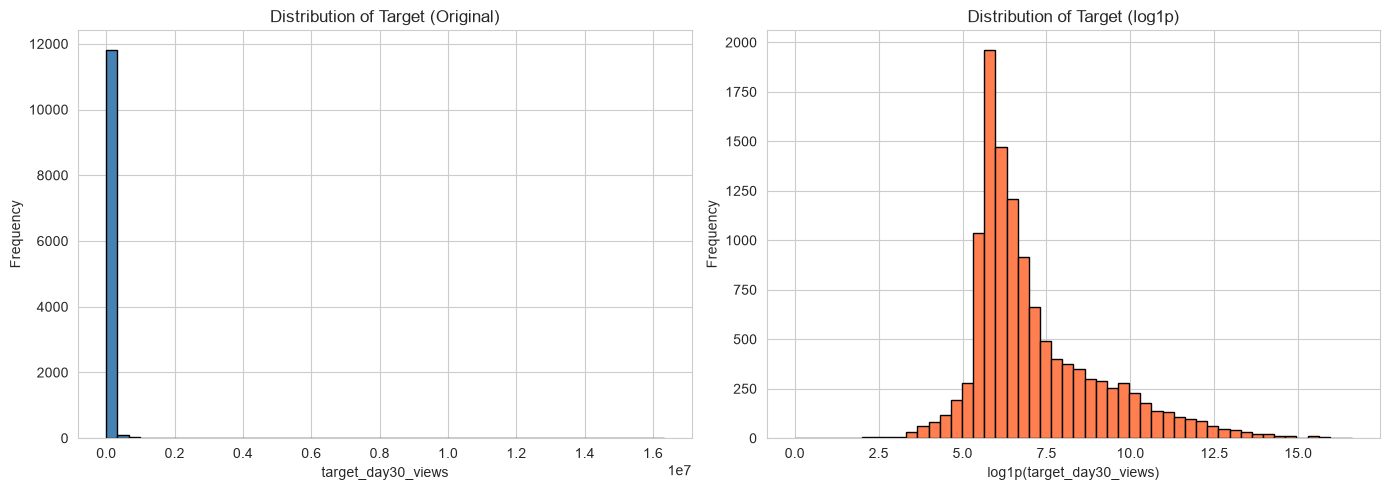

In [5]:
# ============================================
# Target Variable Analysis
# ============================================
print("=" * 60)
print("TARGET: target_day30_views")
print("=" * 60)

print("\nBasic Statistics:")
print(train['target_day30_views'].describe())

print(f"\nSkewness: {train['target_day30_views'].skew():.3f}")
print(f"Kurtosis: {train['target_day30_views'].kurtosis():.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].hist(train['target_day30_views'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Target (Original)')
axes[0].set_xlabel('target_day30_views')
axes[0].set_ylabel('Frequency')

# Log
axes[1].hist(np.log1p(train['target_day30_views']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Distribution of Target (log1p)')
axes[1].set_xlabel('log1p(target_day30_views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Key Insight

The Day-30 view target is extremely right-skewed.

The median is only 668 views, while the mean is approximately 29,229
views. The maximum reaches 16.3 million views, and the target skewness
is 29.133.

This large gap between the median and mean indicates that a relatively
small number of videos receive exceptionally high view counts.

This distribution is important for the modeling stage because RMSE is
particularly sensitive to large prediction errors.

In [6]:
# ============================================
# Engagement Analysis (Days 0-5)
# ============================================
print("=" * 60)
print("ENGAGEMENT DAILY - Overview")
print("=" * 60)

# Days distribution
print("\nDays since post distribution:")
print(engagement['days_since_post'].value_counts().sort_index())

# Unique videos
n_videos_eng = engagement['video_id'].nunique()
n_videos_train = train['video_id'].nunique()
print(f"\nUnique videos in engagement: {n_videos_eng}")
print(f"Unique videos in train:      {n_videos_train}")
print(f"Coverage: {n_videos_eng / n_videos_train * 100:.1f}%")

# Rows per video
rows_per_video = engagement.groupby('video_id').size()
print(f"\nRows per video:")
print(rows_per_video.describe())

# Engagement stats
print("\n" + "=" * 60)
print("ENGAGEMENT METRICS STATISTICS")
print("=" * 60)
print(engagement[['play_count', 'like_count', 'comment_count', 
                  'share_count', 'collect_count', 'download_count', 
                  'whatsapp_share_count']].describe().T)

ENGAGEMENT DAILY - Overview

Days since post distribution:
days_since_post
0     5638
1    14750
2    14726
3    14768
4    14856
5    14751
Name: count, dtype: int64

Unique videos in engagement: 15000
Unique videos in train:      12000
Coverage: 125.0%

Rows per video:
count    15000.000000
mean         5.299267
std          0.551356
min          1.000000
25%          5.000000
50%          5.000000
75%          6.000000
max          6.000000
dtype: float64

ENGAGEMENT METRICS STATISTICS
                        count          mean            std  min    25%    50%     75%         max
play_count            79489.0  13991.800689  145337.531340  0.0  273.0  458.0  1412.0  12627618.0
like_count            79489.0   1311.813899   14571.466661  0.0   14.0   36.0   104.0   1173263.0
comment_count         79489.0     22.337078     225.819114  0.0    0.0    2.0     8.0     25279.0
share_count           79489.0    103.941577    3162.592505  0.0    0.0    0.0     2.0    307472.0
collect_count   

### Key Insight

The engagement table contains 15,000 unique videos, while the training
set contains 12,000 videos.

The number of observations per video varies from 1 to 6 days, with an
average of approximately 5.3 observations per video. Therefore, not every
video has a complete Day 0–5 history.

This missingness must be preserved and handled carefully when creating
daily engagement features.

In [7]:
# ============================================
# Creators Analysis
# ============================================
print("=" * 60)
print("CREATORS DAILY - Overview")
print("=" * 60)

print(f"Unique creators: {creators['author_id'].nunique()}")
print(f"Date range: {creators['date'].min()} to {creators['date'].max()}")

# Rows per creator
rows_per_creator = creators.groupby('author_id').size()
print(f"\nRows per creator:")
print(rows_per_creator.describe())

# Creator stats
print("\n" + "=" * 60)
print("CREATOR STATS")
print("=" * 60)
print(creators[['follower_count', 'following_count', 
                'total_favorited', 'video_count']].describe().T)

# Check enterprise_verified
print("\n" + "=" * 60)
print("enterprise_verified")
print("=" * 60)
print(f"Non-null values: {creators['enterprise_verified'].notna().sum()}")
print(f"Unique values: {creators['enterprise_verified'].unique()}")

CREATORS DAILY - Overview
Unique creators: 1671
Date range: 2024-06-24 to 2024-12-09

Rows per creator:
count    1671.000000
mean      150.907241
std        17.196167
min        48.000000
25%       151.000000
50%       158.000000
75%       160.000000
max       161.000000
dtype: float64

CREATOR STATS
                    count          mean           std    min      25%       50%         75%          max
follower_count   252000.0  1.150920e+05  5.302737e+05  897.0   3602.0   10519.0    40924.00   12551915.0
following_count  252000.0  2.008529e+03  2.674423e+03    0.0    301.0     772.0     2486.00      10000.0
total_favorited  252166.0  4.523682e+06  2.166221e+07    0.0  47419.0  239626.5  1289239.75  497437006.0
video_count      252141.0  9.907009e+02  1.066611e+03    0.0    362.0     678.0     1273.00      19974.0

enterprise_verified
Non-null values: 0
Unique values: [nan]


### Key Insight

Creator statistics vary substantially across creators.

For example, follower count ranges from 897 to more than 12.5 million,
while total favorites range up to approximately 497 million.

The creator table also contains repeated daily snapshots, which means
creator features must be aligned with the video's publication date rather
than simply taking an arbitrary or latest snapshot.

In [49]:
# ============================================
# QUICK CHECK: Engagement Coverage
# ============================================
print("=" * 60)
print("ENGAGEMENT COVERAGE CHECK")
print("=" * 60)

# === 1. Check which videos in train have engagement ===
train_videos = set(train['video_id'])
eng_videos = set(engagement['video_id'])

print(f"Videos in train:      {len(train_videos):,}")
print(f"Videos in engagement: {len(eng_videos):,}")
print(f"Overlap:              {len(train_videos & eng_videos):,}")
print(f"Train without engagement: {len(train_videos - eng_videos):,}")

# === 2. Check day coverage per video ===
days_per_video = engagement.groupby('video_id')['days_since_post'].nunique()
print(f"\nDays per video:")
print(f"  Mean:   {days_per_video.mean():.2f}")
print(f"  Median: {days_per_video.median():.0f}")
print(f"  Min:    {days_per_video.min()}")
print(f"  Max:    {days_per_video.max()}")
print(f"  Videos with < 6 days: {(days_per_video < 6).sum():,}")

ENGAGEMENT COVERAGE CHECK
Videos in train:      12,000
Videos in engagement: 15,000
Overlap:              11,999
Train without engagement: 1

Days per video:
  Mean:   5.30
  Median: 5
  Min:    1
  Max:    6
  Videos with < 6 days: 9,830


In [50]:
# ============================================
# FEATURE ENGINEERING - Step 1: Pivot Engagement
# ============================================
print("=" * 60)
print("PIVOTING ENGAGEMENT DATA")
print("=" * 60)

# Pivot: كل فيديو صف واحد، وكل يوم عمود
def pivot_metric(df, metric_name):
    pivot = df.pivot_table(
        index='video_id', 
        columns='days_since_post', 
        values=metric_name,
        aggfunc='first'
    )
    pivot.columns = [f'{metric_name}_day{c}' for c in pivot.columns]
    return pivot

metrics = ['play_count', 'like_count', 'comment_count', 
           'share_count', 'collect_count', 'download_count', 
           'whatsapp_share_count']

pivoted_dfs = []
for metric in metrics:
    pivoted_dfs.append(pivot_metric(engagement, metric))

engagement_pivot = pd.concat(pivoted_dfs, axis=1).reset_index()

print(f"Pivoted shape: {engagement_pivot.shape}")
print(f"Columns: {list(engagement_pivot.columns)[:15]} ...")

# Check missing days
print("\nMissing values per day:")
for col in ['play_count_day0', 'play_count_day1', 'play_count_day2',
            'play_count_day3', 'play_count_day4', 'play_count_day5']:
    if col in engagement_pivot.columns:
        print(f"  {col}: {engagement_pivot[col].isnull().sum()}")

engagement_pivot.head()

PIVOTING ENGAGEMENT DATA
Pivoted shape: (15000, 43)
Columns: ['video_id', 'play_count_day0', 'play_count_day1', 'play_count_day2', 'play_count_day3', 'play_count_day4', 'play_count_day5', 'like_count_day0', 'like_count_day1', 'like_count_day2', 'like_count_day3', 'like_count_day4', 'like_count_day5', 'comment_count_day0', 'comment_count_day1'] ...

Missing values per day:
  play_count_day0: 9362
  play_count_day1: 250
  play_count_day2: 274
  play_count_day3: 232
  play_count_day4: 144
  play_count_day5: 249


,video_id,play_count_day0,play_count_day1,play_count_day2,play_count_day3,play_count_day4,play_count_day5,like_count_day0,like_count_day1,like_count_day2,like_count_day3,like_count_day4,like_count_day5,comment_count_day0,comment_count_day1,comment_count_day2,comment_count_day3,comment_count_day4,comment_count_day5,share_count_day0,share_count_day1,share_count_day2,share_count_day3,share_count_day4,share_count_day5,collect_count_day0,collect_count_day1,collect_count_day2,collect_count_day3,collect_count_day4,collect_count_day5,download_count_day0,download_count_day1,download_count_day2,download_count_day3,download_count_day4,download_count_day5,whatsapp_share_count_day0,whatsapp_share_count_day1,whatsapp_share_count_day2,whatsapp_share_count_day3,whatsapp_share_count_day4,whatsapp_share_count_day5
0,7384086821132717358,105696.0,330084.0,390753.0,464862.0,475386.0,478085.0,6249.0,25291.0,32925.0,45741.0,46896.0,47109.0,23.0,71.0,93.0,137.0,143.0,143.0,1113.0,3689.0,4476.0,5756.0,5907.0,5936.0,1737.0,6421.0,8082.0,10699.0,10926.0,10987.0,59.0,214.0,272.0,358.0,366.0,368.0,5.0,25.0,30.0,33.0,33.0,34.0
1,7384175589206265118,138.0,323.0,388.0,447.0,492.0,557.0,7.0,16.0,17.0,18.0,19.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7384177529092951338,10524.0,11045.0,11290.0,11430.0,11610.0,11743.0,1388.0,1449.0,1465.0,1475.0,1490.0,1506.0,70.0,73.0,74.0,74.0,77.0,77.0,52.0,54.0,54.0,54.0,54.0,54.0,55.0,55.0,55.0,55.0,56.0,58.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7384193780057984287,273.0,356.0,378.0,397.0,410.0,423.0,36.0,41.0,42.0,42.0,42.0,42.0,1.0,2.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,6.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7384193851700956447,541.0,1414.0,1959.0,2258.0,2467.0,2697.0,16.0,32.0,36.0,38.0,42.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,5.0,9.0,9.0,11.0,11.0,1.0,3.0,4.0,5.0,6.0,6.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Key Insight

After pivoting the engagement table, each video is represented by one row
with separate columns for Days 0–5.

The pivot reveals substantial missingness in the early engagement history,
especially for Day 0, where `play_count_day0` is missing for many videos.

Therefore, Day 0 should not be assumed to be available for every video.
The feature engineering step must handle these missing observations
explicitly rather than treating them as observed zero engagement.

## 4. Early Engagement Feature Engineering

The daily engagement table is transformed into video-level features.

The features describe three aspects of early performance:

1. Engagement level — how many views and interactions the video has received.
2. Growth — how engagement changes across the observed days.
3. Engagement intensity — interactions relative to the number of views.

Because some videos do not contain observations for every day, missing
daily values are preserved during the initial feature construction and
handled explicitly where ratios or growth rates are calculated.

In [10]:
# ============================================
# FEATURE ENGINEERING - Step 2: Build Features
# ============================================
print("=" * 60)
print("BUILDING FEATURES FROM ENGAGEMENT")
print("=" * 60)

def safe_divide(a, b):
    """Safely divide, return 0 if denominator is 0."""
    return np.where((b == 0) | pd.isna(b), 0, a / b)

# === 1. آخر يوم (day5) — الأقوى ===
feat = engagement_pivot[['video_id']].copy()

# Play metrics
feat['play_last'] = engagement_pivot['play_count_day5']
feat['play_first'] = engagement_pivot['play_count_day1']  # day1 بدل day0
feat['play_max'] = engagement_pivot[['play_count_day1', 'play_count_day2',
                                      'play_count_day3', 'play_count_day4',
                                      'play_count_day5']].max(axis=1)
feat['play_mean'] = engagement_pivot[['play_count_day1', 'play_count_day2',
                                       'play_count_day3', 'play_count_day4',
                                       'play_count_day5']].mean(axis=1)
feat['play_std'] = engagement_pivot[['play_count_day1', 'play_count_day2',
                                      'play_count_day3', 'play_count_day4',
                                      'play_count_day5']].std(axis=1)

# Growth ratios
feat['play_growth_5_1'] = safe_divide(
    engagement_pivot['play_count_day5'], 
    engagement_pivot['play_count_day1']
)
feat['play_growth_5_3'] = safe_divide(
    engagement_pivot['play_count_day5'], 
    engagement_pivot['play_count_day3']
)
feat['play_growth_3_1'] = safe_divide(
    engagement_pivot['play_count_day3'], 
    engagement_pivot['play_count_day1']
)

# Daily differences
feat['play_diff_5_4'] = engagement_pivot['play_count_day5'] - engagement_pivot['play_count_day4']
feat['play_diff_4_3'] = engagement_pivot['play_count_day4'] - engagement_pivot['play_count_day3']
feat['play_diff_3_2'] = engagement_pivot['play_count_day3'] - engagement_pivot['play_count_day2']

# === 2. Interaction Ratios (Day 5) ===
feat['like_ratio'] = safe_divide(engagement_pivot['like_count_day5'], 
                                  engagement_pivot['play_count_day5'])
feat['comment_ratio'] = safe_divide(engagement_pivot['comment_count_day5'], 
                                     engagement_pivot['play_count_day5'])
feat['share_ratio'] = safe_divide(engagement_pivot['share_count_day5'], 
                                   engagement_pivot['play_count_day5'])
feat['collect_ratio'] = safe_divide(engagement_pivot['collect_count_day5'], 
                                     engagement_pivot['play_count_day5'])
feat['download_ratio'] = safe_divide(engagement_pivot['download_count_day5'], 
                                      engagement_pivot['play_count_day5'])
feat['whatsapp_ratio'] = safe_divide(engagement_pivot['whatsapp_share_count_day5'], 
                                      engagement_pivot['play_count_day5'])

# === 3. Other metrics (Day 5) ===
feat['like_last'] = engagement_pivot['like_count_day5']
feat['comment_last'] = engagement_pivot['comment_count_day5']
feat['share_last'] = engagement_pivot['share_count_day5']
feat['collect_last'] = engagement_pivot['collect_count_day5']
feat['download_last'] = engagement_pivot['download_count_day5']
feat['whatsapp_last'] = engagement_pivot['whatsapp_share_count_day5']

# === 4. Total engagement ===
feat['total_engagement_last'] = (
    feat['like_last'] + feat['comment_last'] + feat['share_last'] +
    feat['collect_last'] + feat['download_last'] + feat['whatsapp_last']
)

feat['engagement_ratio'] = safe_divide(feat['total_engagement_last'], feat['play_last'])

print(f"Features built: {feat.shape[1] - 1}")
print(f"\nFirst 10 features:")
print(list(feat.columns)[:10])
print(f"\nSample:")
feat.head()

BUILDING FEATURES FROM ENGAGEMENT
Features built: 25

First 10 features:
['video_id', 'play_last', 'play_first', 'play_max', 'play_mean', 'play_std', 'play_growth_5_1', 'play_growth_5_3', 'play_growth_3_1', 'play_diff_5_4']

Sample:


,video_id,play_last,play_first,play_max,play_mean,play_std,play_growth_5_1,play_growth_5_3,play_growth_3_1,play_diff_5_4,play_diff_4_3,play_diff_3_2,like_ratio,comment_ratio,share_ratio,collect_ratio,download_ratio,whatsapp_ratio,like_last,comment_last,share_last,collect_last,download_last,whatsapp_last,total_engagement_last,engagement_ratio
0,7384086821132717358,478085.0,330084.0,478085.0,427834.0,65359.566151,1.448374,1.028445,1.408314,2699.0,10524.0,74109.0,0.098537,0.000299,0.012416,0.022981,0.000770,0.000071,47109.0,143.0,5936.0,10987.0,368.0,34.0,64577.0,0.135074
1,7384175589206265118,557.0,323.0,557.0,441.4,90.588631,1.724458,1.246085,1.383901,65.0,45.0,59.0,0.034111,0.000000,0.000000,0.003591,0.000000,0.000000,19.0,0.0,0.0,2.0,0.0,0.0,21.0,0.037702
2,7384177529092951338,11743.0,11045.0,11743.0,11423.6,272.941935,1.063196,1.027384,1.034857,133.0,180.0,140.0,0.128247,0.006557,0.004598,0.004939,0.000085,0.000000,1506.0,77.0,54.0,58.0,1.0,0.0,1696.0,0.144426
3,7384193780057984287,423.0,356.0,423.0,392.8,26.451843,1.188202,1.065491,1.115169,13.0,13.0,19.0,0.099291,0.007092,0.000000,0.014184,0.000000,0.000000,42.0,3.0,0.0,6.0,0.0,0.0,51.0,0.120567
4,7384193851700956447,2697.0,1414.0,2697.0,2159.0,497.276080,1.907355,1.194420,1.596888,230.0,209.0,299.0,0.016685,0.000000,0.004079,0.002225,0.000371,0.000371,45.0,0.0,11.0,6.0,1.0,1.0,64.0,0.023730


In [51]:
# ============================================
# FEATURE ENGINEERING - Step 3: Merge All (AS-OF)
# ============================================
from pandas import merge_asof
from datetime import timedelta

print("=" * 60)
print("MERGING ALL DATASETS (AS-OF)")
print("=" * 60)

# === 1. Start with train ===
df = train.copy()
print(f"Train: {df.shape}")

# === 2. Merge engagement features ===
df = df.merge(feat, on='video_id', how='left')
print(f"After engagement merge: {df.shape}")

# === 3. Prepare creators (as-of merge) ===
# Convert dates
creators['date'] = pd.to_datetime(creators['date'])
df['create_date'] = pd.to_datetime(df['create_date'])

# Sort by date (required for merge_asof)
creators_sorted = creators.sort_values('date').reset_index(drop=True)
df_sorted = df.sort_values('create_date').reset_index(drop=True)

# === 4. Merge_asof: for each video, get creator stats <= create_date ===
df_merged = merge_asof(
    df_sorted,
    creators_sorted[['author_id', 'date', 
                     'follower_count', 'following_count', 
                     'total_favorited', 'video_count']],
    left_on='create_date',
    right_on='date',
    by='author_id',
    direction='backward'   # آخر snapshot قبل أو في يوم الفيديو
)

# Drop the extra 'date' column
df_merged = df_merged.drop(columns=['date'])

print(f"After creators merge (as-of): {df_merged.shape}")

# === 5. Check ===
print(f"\nFinal shape: {df_merged.shape}")
print(f"\nMissing values (top 10):")
missing = df_merged.isnull().sum().sort_values(ascending=False).head(10)
print(missing)

# === 6. Check that we have creator data ===
print(f"\nVideos without creator match: {df_merged['follower_count'].isnull().sum()}")

# === 7. Set index ===
df = df_merged.set_index('video_id')
print(f"\nFinal index: video_id")

df.head()

MERGING ALL DATASETS (AS-OF)
Train: (12000, 27)
After engagement merge: (12000, 52)
After creators merge (as-of): (12000, 56)

Final shape: (12000, 56)

Missing values (top 10):
question_count    4047
hashtag_count     4047
emoji_count       4047
speaking_rate     4047
word_count        4047
music_owner_id    2972
play_diff_3_2      404
play_diff_5_4      317
play_diff_4_3      293
collect_last       210
dtype: int64

Videos without creator match: 0

Final index: video_id


,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,music_selected_from,music_author,music_owner_id,music_id,word_count,emoji_count,question_count,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear,target_day30_views,play_last,play_first,play_max,play_mean,play_std,play_growth_5_1,play_growth_5_3,play_growth_3_1,play_diff_5_4,play_diff_4_3,play_diff_3_2,like_ratio,comment_ratio,share_ratio,collect_ratio,download_ratio,whatsapp_ratio,like_last,comment_last,share_last,collect_last,download_last,whatsapp_last,total_engagement_last,engagement_ratio,follower_count,following_count,total_favorited,video_count
video_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7384281153810730282,6964376699194868741,2024-06-24 22:42:19,2024-06-24,17.051,540p,en,1,0.0,0,original,BR_OpenIce,6.964377e+18,7.384281e+18,3.0,4.0,0.0,3.0,0.000000,Sports_Fitness,0.001884,0.980621,0.003171,0.001388,0.002183,0.000347,20202,19387.0,17160.0,19387.0,18609.4,901.088120,1.129779,1.022305,1.105128,191.0,232.0,624.0,0.120957,0.004075,0.002321,0.006706,0.000825,0.000000,2345.0,79.0,45.0,130.0,16.0,0.0,2615.0,0.134884,321943.0,78.0,45290122,4314.0
7384256742231674142,1355171,2024-06-24 21:07:52,2024-06-24,8.800,540p,en,1,0.0,0,single_song,Jane 💛,6.818816e+18,7.348740e+18,6.0,2.0,0.0,4.0,0.000000,Others,0.002821,0.900877,0.003702,0.003531,0.014318,0.000481,375,313.0,292.0,313.0,305.6,8.706320,1.071918,1.019544,1.051370,0.0,6.0,4.0,0.130990,0.009585,0.006390,0.015974,0.003195,0.000000,41.0,3.0,2.0,5.0,1.0,0.0,52.0,0.166134,27222.0,10000.0,329388,2076.0
7384240278447623454,6716318631842202629,2024-06-24 20:03:56,2024-06-24,41.267,540p,en,1,0.0,0,original,marina,6.716319e+18,7.384240e+18,151.0,0.0,1.0,0.0,7.366661,Others,0.019063,0.755502,0.005165,0.004564,0.042880,0.001129,116377,86780.0,58273.0,86780.0,73293.0,10709.862581,1.489197,1.191787,1.249550,7529.0,6436.0,3469.0,0.149182,0.000611,0.000841,0.001417,0.000081,0.000000,12946.0,53.0,73.0,123.0,7.0,0.0,13202.0,0.152132,253717.0,34.0,19732791,1223.0
7384297959522929966,6964376699194868741,2024-06-24 23:47:36,2024-06-24,12.834,540p,en,1,0.0,0,original,BR_OpenIce,6.964377e+18,7.384298e+18,58.0,1.0,1.0,0.0,6.467197,Sports_Fitness,0.002758,0.925089,0.004872,0.002093,0.004167,0.000611,165913,161773.0,128323.0,161773.0,151729.4,13894.413349,1.260670,1.023472,1.231759,1113.0,2597.0,8235.0,0.059404,0.000989,0.000964,0.001836,0.000117,0.000006,9610.0,160.0,156.0,297.0,19.0,1.0,10243.0,0.063317,321943.0,78.0,45290122,4314.0
7384219266125548842,6613162,2024-06-24 18:42:12,2024-06-24,4.550,540p,un,0,0.0,0,single_song,.,7.094922e+18,7.135481e+18,7.0,0.0,2.0,0.0,5.274725,Life_hacks_Personal_growth,0.002644,0.944287,0.003380,0.003404,0.014776,0.000416,51,33.0,20.0,33.0,26.0,5.477226,1.650000,1.222222,1.350000,4.0,2.0,6.0,0.060606,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,0.0,0.0,0.0,0.0,0.0,2.0,0.060606,10485.0,287.0,321032,546.0


In [12]:
# ============================================
# PREPROCESSING + BASELINE MODEL
# ============================================
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import lightgbm as lgb

print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

# === 1. Drop useless columns ===
drop_cols = [
    'author_id',           # مش feature
    'create_time',         # تاريخ (نستخدم create_date?)
    'create_date',         # تاريخ
    'music_owner_id',      # 25% missing + IDs عشوائية
    'music_id',            # IDs عشوائية
    'target_day30_views',  # target (نفصله)
]
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['target_day30_views'].copy()

print(f"Features after dropping: {df_clean.shape}")

# === 2. Handle categorical columns ===
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {cat_cols}")

# Encode categoricals (simple label encoding)
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = df_clean[col].fillna('missing').astype(str)
    df_clean[col] = le.fit_transform(df_clean[col])

print(f"After encoding: {df_clean.shape}")

# === 3. Handle numeric missing values ===
# Fill with median for numeric
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f"After filling NaN: {df_clean.isnull().sum().sum()} missing values left")

# === 4. Log transform target ===
y_log = np.log1p(y)
print(f"\nTarget log-transform applied")
print(f"Original target: min={y.min()}, max={y.max()}, mean={y.mean():.0f}")
print(f"Log target:      min={y_log.min():.2f}, max={y_log.max():.2f}, mean={y_log.mean():.2f}")

# === 5. Baseline Model: LightGBM + 5-Fold CV ===
print("\n" + "=" * 60)
print("BASELINE: LightGBM + 5-Fold CV")
print("=" * 60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []
oof_preds = np.zeros(len(df_clean))

for fold, (train_idx, val_idx) in enumerate(kf.split(df_clean), 1):
    X_train, X_val = df_clean.iloc[train_idx], df_clean.iloc[val_idx]
    y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]
    
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    # Predict in log space
    preds_log = model.predict(X_val)
    oof_preds[val_idx] = preds_log
    
    # RMSE in log space
    rmse_log = np.sqrt(mean_squared_error(y_val, preds_log))
    
    # RMSE in original space
    rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds_log)))
    
    rmse_scores.append(rmse_orig)
    print(f"Fold {fold}: RMSE (log)={rmse_log:.4f}, RMSE (orig)={rmse_orig:,.0f}")

print(f"\n{'=' * 60}")
print(f"MEAN RMSE (original): {np.mean(rmse_scores):,.0f}")
print(f"{'=' * 60}")
print(f"\nCompare to Emad's 90,142 baseline")
if np.mean(rmse_scores) < 90142:
    print("✅ BEATING baseline!")
else:
    print("❌ Need improvement")

PREPROCESSING
Features after dropping: (12000, 49)

Categorical columns: ['ratio', 'desc_language', 'music_selected_from', 'music_author', 'topic']
After encoding: (12000, 49)
After filling NaN: 0 missing values left

Target log-transform applied
Original target: min=0, max=16310546, mean=29229
Log target:      min=0.00, max=16.61, mean=7.14

BASELINE: LightGBM + 5-Fold CV


C:\Users\ino0i\AppData\Local\Temp\ipykernel_24280\512904592.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


Fold 1: RMSE (log)=0.2914, RMSE (orig)=128,196
Fold 2: RMSE (log)=0.3126, RMSE (orig)=146,573
Fold 3: RMSE (log)=0.2745, RMSE (orig)=54,634
Fold 4: RMSE (log)=0.3113, RMSE (orig)=259,194
Fold 5: RMSE (log)=0.2716, RMSE (orig)=108,767

MEAN RMSE (original): 139,473

Compare to Emad's 90,142 baseline
❌ Need improvement


In [13]:
# ============================================
# IMPROVED MODELS: XGBoost + CatBoost + Ensemble
# ============================================
import xgboost as xgb
from catboost import CatBoostRegressor

print("=" * 60)
print("MULTIPLE MODELS + ENSEMBLE")
print("=" * 60)

# === Helper: evaluate model ===
def evaluate_model(model, X_train, X_val, y_train_log, y_val_log, y_val_orig, name="Model"):
    model.fit(X_train, y_train_log)
    preds_log = model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val_log, preds_log))
    rmse_orig = np.sqrt(mean_squared_error(y_val_orig, np.expm1(preds_log)))
    
    return preds_log, rmse_log, rmse_orig

# === Store OOF predictions ===
models_preds = {
    'lgbm': np.zeros(len(df_clean)),
    'xgb': np.zeros(len(df_clean)),
    'cat': np.zeros(len(df_clean)),
}

# === 5-Fold CV with 3 models ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {'lgbm': [], 'xgb': [], 'cat': []}

for fold, (train_idx, val_idx) in enumerate(kf.split(df_clean), 1):
    X_train, X_val = df_clean.iloc[train_idx], df_clean.iloc[val_idx]
    y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
    y_val_orig = y.iloc[val_idx]
    
    # LightGBM
    lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, 
                              num_leaves=31, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train_log)
    preds_lgbm = lgbm.predict(X_val)
    models_preds['lgbm'][val_idx] = preds_lgbm
    
    # XGBoost
    xgbr = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, 
                             max_depth=6, random_state=42, verbosity=0)
    xgbr.fit(X_train, y_train_log)
    preds_xgb = xgbr.predict(X_val)
    models_preds['xgb'][val_idx] = preds_xgb
    
    # CatBoost
    cbr = CatBoostRegressor(n_estimators=500, learning_rate=0.05, 
                             depth=6, random_state=42, verbose=0)
    cbr.fit(X_train, y_train_log)
    preds_cat = cbr.predict(X_val)
    models_preds['cat'][val_idx] = preds_cat
    
    # Ensemble (average)
    preds_ens = (preds_lgbm + preds_xgb + preds_cat) / 3
    
    # Scores
    for name, preds in [('lgbm', preds_lgbm), ('xgb', preds_xgb), 
                         ('cat', preds_cat), ('ensemble', preds_ens)]:
        rmse_orig = np.sqrt(mean_squared_error(y_val_orig, np.expm1(preds)))
        if name not in results:
            results[name] = []
        results[name].append(rmse_orig)
    
    print(f"Fold {fold}: LGBM={results['lgbm'][-1]:,.0f} | "
          f"XGB={results['xgb'][-1]:,.0f} | "
          f"CAT={results['cat'][-1]:,.0f} | "
          f"ENS={results['ensemble'][-1]:,.0f}")

# === Final results ===
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
for name, scores in results.items():
    print(f"{name.upper():12s}: Mean RMSE = {np.mean(scores):>10,.0f}")

print(f"\nBaseline (Emad): 90,142")

best_model = min(results, key=lambda k: np.mean(results[k]))
print(f"\n🏆 Best model: {best_model.upper()} ({np.mean(results[best_model]):,.0f})")

if np.mean(results[best_model]) < 90142:
    print("✅ BEATING baseline!")
else:
    print("⚠️ Still above baseline")

MULTIPLE MODELS + ENSEMBLE
Fold 1: LGBM=128,196 | XGB=130,405 | CAT=139,413 | ENS=130,339
Fold 2: LGBM=146,573 | XGB=150,873 | CAT=157,384 | ENS=148,000
Fold 3: LGBM=54,634 | XGB=51,590 | CAT=44,059 | ENS=44,441
Fold 4: LGBM=259,194 | XGB=255,992 | CAT=262,584 | ENS=258,617
Fold 5: LGBM=108,767 | XGB=96,304 | CAT=103,906 | ENS=95,524

FINAL RESULTS
LGBM        : Mean RMSE =    139,473
XGB         : Mean RMSE =    137,033
CAT         : Mean RMSE =    141,469
ENSEMBLE    : Mean RMSE =    135,384

Baseline (Emad): 90,142

🏆 Best model: ENSEMBLE (135,384)
⚠️ Still above baseline


In [14]:
# ============================================
# TRY DIFFERENT TARGET TRANSFORMATIONS
# ============================================
from scipy import stats

print("=" * 60)
print("TESTING DIFFERENT TARGET TRANSFORMATIONS")
print("=" * 60)

# Define transformations
transformations = {
    'log1p': (np.log1p, np.expm1),
    'log10': (lambda x: np.log10(x + 1), lambda x: 10**x - 1),
    'sqrt': (np.sqrt, lambda x: x**2),
    'cbrt': (np.cbrt, lambda x: x**3),
}

# Quick LightGBM test with each transformation
results = {}

for name, (forward, inverse) in transformations.items():
    y_transformed = forward(y)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(df_clean):
        X_train, X_val = df_clean.iloc[train_idx], df_clean.iloc[val_idx]
        y_train_t = y_transformed.iloc[train_idx]
        y_val_orig = y.iloc[val_idx]
        
        model = lgb.LGBMRegressor(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, random_state=42, verbose=-1
        )
        model.fit(X_train, y_train_t)
        preds_t = model.predict(X_val)
        preds_orig = inverse(preds_t)
        
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds_orig))
        scores.append(rmse)
    
    results[name] = np.mean(scores)
    print(f"{name:8s}: RMSE = {results[name]:>10,.0f}")

print("\n" + "=" * 60)
best = min(results, key=results.get)
print(f"🏆 Best transformation: {best} ({results[best]:,.0f})")

TESTING DIFFERENT TARGET TRANSFORMATIONS
log1p   : RMSE =    139,473
log10   : RMSE =    140,106
sqrt    : RMSE =    134,522
cbrt    : RMSE =    134,120

🏆 Best transformation: cbrt (134,120)


In [15]:
# ============================================
# ADVANCED FEATURE ENGINEERING - Step 4
# ============================================
print("=" * 60)
print("ADVANCED FEATURES")
print("=" * 60)

# نحتاج نرجّع للـ df الأصلي (train + engagement + creators)
# عشان نضيف features جديدة

df_adv = df.copy()

# === 1. TIME FEATURES ===
df_adv['create_time'] = pd.to_datetime(df_adv['create_time'])
df_adv['hour'] = df_adv['create_time'].dt.hour
df_adv['day_of_week'] = df_adv['create_time'].dt.dayofweek
df_adv['month'] = df_adv['create_time'].dt.month
df_adv['is_weekend'] = (df_adv['day_of_week'] >= 5).astype(int)

print("✅ Time features added")

# === 2. CREATOR-BASED RATIOS ===
# follower / following
df_adv['follower_following_ratio'] = safe_divide(
    df_adv['follower_count'], df_adv['following_count']
)

# total_favorited / video_count (متوسط favorites لكل فيديو)
df_adv['favorited_per_video'] = safe_divide(
    df_adv['total_favorited'], df_adv['video_count']
)

# play_last / follower_count (فيديو بيوصل لكام من متابعين الـ creator)
df_adv['play_to_follower'] = safe_divide(
    df_adv['play_last'], df_adv['follower_count']
)

# play_last / total_favorited
df_adv['play_to_favorited'] = safe_divide(
    df_adv['play_last'], df_adv['total_favorited']
)

print("✅ Creator ratio features added")

# === 3. LOG TRANSFORMS للمتغيرات المهمة ===
df_adv['log_follower_count'] = np.log1p(df_adv['follower_count'])
df_adv['log_total_favorited'] = np.log1p(df_adv['total_favorited'])
df_adv['log_video_count'] = np.log1p(df_adv['video_count'])
df_adv['log_play_last'] = np.log1p(df_adv['play_last'])
df_adv['log_play_mean'] = np.log1p(df_adv['play_mean'])

print("✅ Log transforms added")

# === 4. ENGAGEMENT DIVERSITY ===
eng_cols = ['like_last', 'comment_last', 'share_last', 'collect_last', 
            'download_last', 'whatsapp_last']
df_adv['engagement_diversity'] = (df_adv[eng_cols] > 0).sum(axis=1)

print("✅ Engagement diversity added")

# === 5. TOPIC POPULARITY ===
# متوسط target لكل topic
topic_stats = df_adv.groupby('topic')['target_day30_views'].agg(['mean', 'median', 'count'])
topic_stats.columns = ['topic_mean_views', 'topic_median_views', 'topic_count']
df_adv = df_adv.merge(topic_stats, on='topic', how='left')

print("✅ Topic popularity added")

# === 6. INTERACTION FEATURES ===
df_adv['play_x_like'] = df_adv['play_last'] * df_adv['like_ratio']
df_adv['play_x_share'] = df_adv['play_last'] * df_adv['share_ratio']
df_adv['log_play_x_follower'] = df_adv['log_play_last'] * df_adv['log_follower_count']

print("✅ Interaction features added")

# === 7. الداتا الجديدة ===
print(f"\nNew shape: {df_adv.shape}")
print(f"New features added: {df_adv.shape[1] - df.shape[1]}")

# === 8. شوف الأعمدة الجديدة ===
new_cols = [c for c in df_adv.columns if c not in df.columns]
print(f"\nNew columns:")
for c in new_cols:
    print(f"  - {c}")

ADVANCED FEATURES
✅ Time features added
✅ Creator ratio features added
✅ Log transforms added
✅ Engagement diversity added
✅ Topic popularity added
✅ Interaction features added

New shape: (12000, 75)
New features added: 20

New columns:
  - hour
  - day_of_week
  - month
  - is_weekend
  - follower_following_ratio
  - favorited_per_video
  - play_to_follower
  - play_to_favorited
  - log_follower_count
  - log_total_favorited
  - log_video_count
  - log_play_last
  - log_play_mean
  - engagement_diversity
  - topic_mean_views
  - topic_median_views
  - topic_count
  - play_x_like
  - play_x_share
  - log_play_x_follower


In [16]:
# ============================================
# IMPROVED PIPELINE WITH ADVANCED FEATURES
# ============================================
from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("REBUILDING PIPELINE WITH ADVANCED FEATURES")
print("=" * 60)

# === 1. Prepare df for modeling ===
df_model = df_adv.copy()

# Drop useless columns
drop_cols = [
    'author_id', 'create_time', 'create_date',
    'music_owner_id', 'music_id',
    'target_day30_views',  # target
    'topic',  # نستخدم topic_mean_views بدل الاسم
]
drop_cols = [c for c in drop_cols if c in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

# === 2. Encode categoricals ===
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical: {cat_cols}")

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('missing').astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# === 3. Fill NaN ===
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

print(f"Shape: {df_model.shape}")
print(f"Missing: {df_model.isnull().sum().sum()}")

# === 4. Target: cbrt ===
y_cbrt = np.cbrt(y)

# === 5. 5-Fold CV with cbrt ===
print("\n" + "=" * 60)
print("MODELS WITH ADVANCED FEATURES + cbrt TARGET")
print("=" * 60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {'lgbm': [], 'xgb': [], 'cat': [], 'ensemble': []}

for fold, (train_idx, val_idx) in enumerate(kf.split(df_model), 1):
    X_train, X_val = df_model.iloc[train_idx], df_model.iloc[val_idx]
    y_train_t = y_cbrt.iloc[train_idx]
    y_val_orig = y.iloc[val_idx]
    
    # LightGBM
    lgbm = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.03,
        num_leaves=63, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train_t)
    preds_lgbm = lgbm.predict(X_val) ** 3
    
    # XGBoost
    xgbr = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.03,
        max_depth=7, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbosity=0
    )
    xgbr.fit(X_train, y_train_t)
    preds_xgb = xgbr.predict(X_val) ** 3
    
    # CatBoost
    cbr = CatBoostRegressor(
        n_estimators=1000, learning_rate=0.03,
        depth=7, random_state=42, verbose=0
    )
    cbr.fit(X_train, y_train_t)
    preds_cat = cbr.predict(X_val) ** 3
    
    # Ensemble
    preds_ens = (preds_lgbm + preds_xgb + preds_cat) / 3
    
    # Scores
    for name, preds in [('lgbm', preds_lgbm), ('xgb', preds_xgb), 
                         ('cat', preds_cat), ('ensemble', preds_ens)]:
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
        results[name].append(rmse)
    
    print(f"Fold {fold}: LGBM={results['lgbm'][-1]:>10,.0f} | "
          f"XGB={results['xgb'][-1]:>10,.0f} | "
          f"CAT={results['cat'][-1]:>10,.0f} | "
          f"ENS={results['ensemble'][-1]:>10,.0f}")

# === 6. Final ===
print("\n" + "=" * 60)
print("FINAL RESULTS - ADVANCED FEATURES")
print("=" * 60)
for name, scores in results.items():
    print(f"{name.upper():12s}: {np.mean(scores):>10,.0f}")

print(f"\n{'Baseline (Emad)':12s}: {90142:>10,}")

best = min(results, key=lambda k: np.mean(results[k]))
print(f"\n🏆 Best: {best.upper()} ({np.mean(results[best]):,.0f})")

if np.mean(results[best]) < 90142:
    print("✅ BEATING baseline!")
else:
    print(f"⚠️ Gap: {np.mean(results[best]) - 90142:,.0f}")

REBUILDING PIPELINE WITH ADVANCED FEATURES
Categorical: ['ratio', 'desc_language', 'music_selected_from', 'music_author']
Shape: (12000, 68)
Missing: 0

MODELS WITH ADVANCED FEATURES + cbrt TARGET


C:\Users\ino0i\AppData\Local\Temp\ipykernel_24280\245018081.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()


Fold 1: LGBM=   134,477 | XGB=   156,673 | CAT=   149,087 | ENS=   136,841
Fold 2: LGBM=   149,027 | XGB=   173,718 | CAT=   145,574 | ENS=   148,138
Fold 3: LGBM=    57,346 | XGB=    88,394 | CAT=    42,895 | ENS=    51,443
Fold 4: LGBM=   250,896 | XGB=   308,438 | CAT=   262,094 | ENS=   272,538
Fold 5: LGBM=    99,693 | XGB=   125,477 | CAT=    80,537 | ENS=    95,144

FINAL RESULTS - ADVANCED FEATURES
LGBM        :    138,288
XGB         :    170,540
CAT         :    136,037
ENSEMBLE    :    140,821

Baseline (Emad):     90,142

🏆 Best: CAT (136,037)
⚠️ Gap: 45,895


FEATURE IMPORTANCE

Top 25 Features:
         feature  importance
 play_growth_5_3         898
    music_author         708
   play_diff_5_4         660
        play_max         655
  follower_count         594
     video_count         578
 following_count         556
 play_growth_5_1         491
        duration         445
 play_growth_3_1         433
   play_diff_4_3         431
 total_favorited         427
        surprise         417
         disgust         415
         sadness         413
      play_first         412
      like_ratio         407
   collect_ratio         388
            fear         374
        play_std         341
           anger         335
             joy         335
engagement_ratio         321
   comment_ratio         288
     share_ratio         282


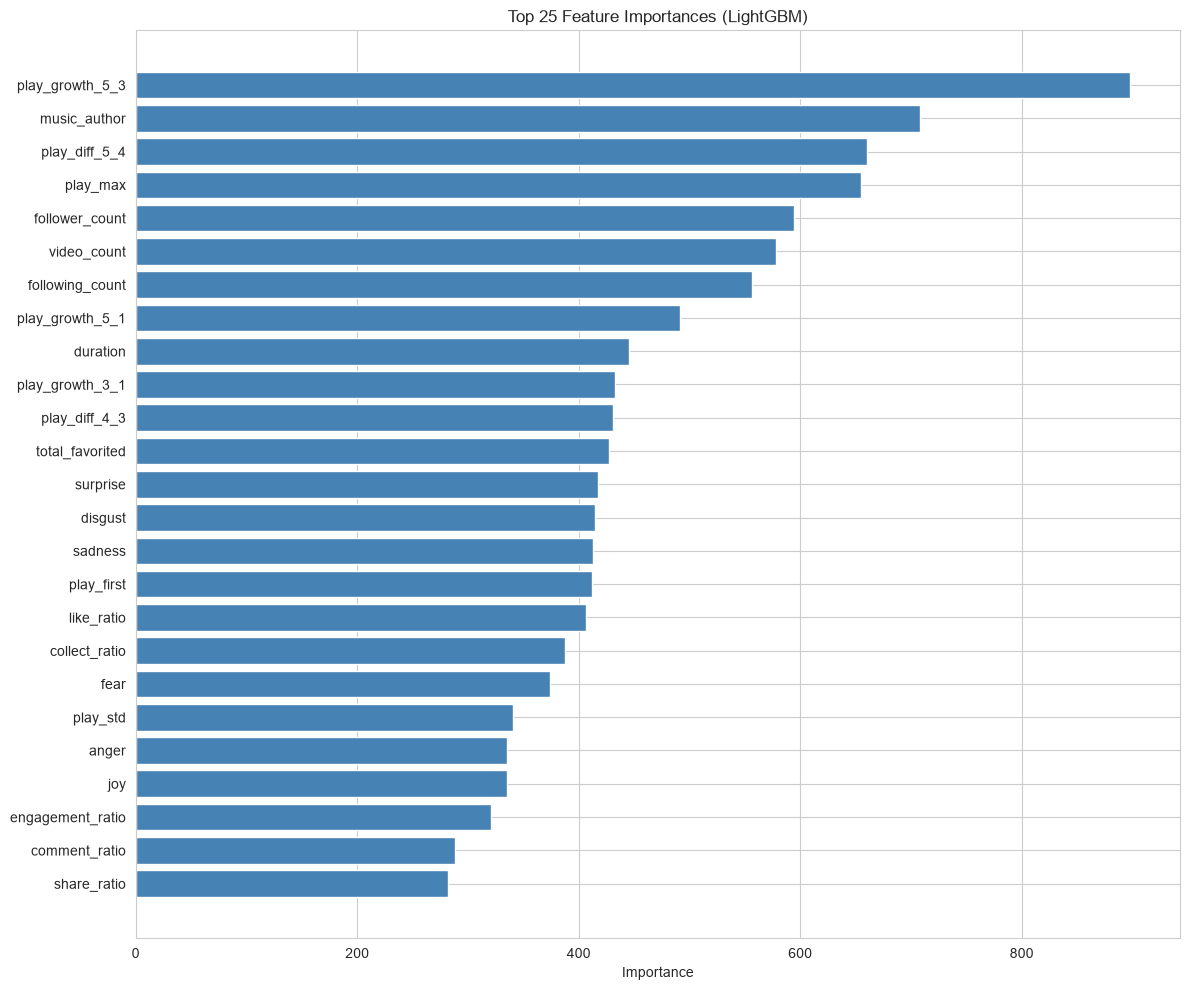

In [17]:
# ============================================
# FEATURE IMPORTANCE (from LightGBM)
# ============================================
import lightgbm as lgb

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Train model on full data to get feature importance
model_fi = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, random_state=42, verbose=-1
)
model_fi.fit(df_clean, y_log)

# Get importance
importance_df = pd.DataFrame({
    'feature': df_clean.columns,
    'importance': model_fi.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 25 Features:")
print(importance_df.head(25).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
top_n = 25
top_features = importance_df.head(top_n)
ax.barh(range(top_n), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

CORRELATION MATRIX

TOP 20 FEATURES CORRELATED WITH TARGET
play_max                 0.970685
play_last                0.970460
play_mean                0.944955
play_std                 0.937192
play_diff_3_2            0.893192
play_diff_4_3            0.888992
like_last                0.879808
total_engagement_last    0.858997
play_diff_5_4            0.813129
play_first               0.764050
collect_last             0.678033
share_last               0.639193
whatsapp_last            0.586969
comment_last             0.507535
download_last            0.401852
follower_count           0.269565
total_favorited          0.263953
play_growth_5_1          0.133310
play_growth_3_1          0.111787
share_ratio              0.061971
Name: target_day30_views, dtype: float64

TOP 10 NEGATIVE CORRELATIONS
anger                 -0.002557
fear                  -0.006031
created_by_ai         -0.006063
emoji_count           -0.008494
ratio                 -0.010273
music_selected_from   -0.01038

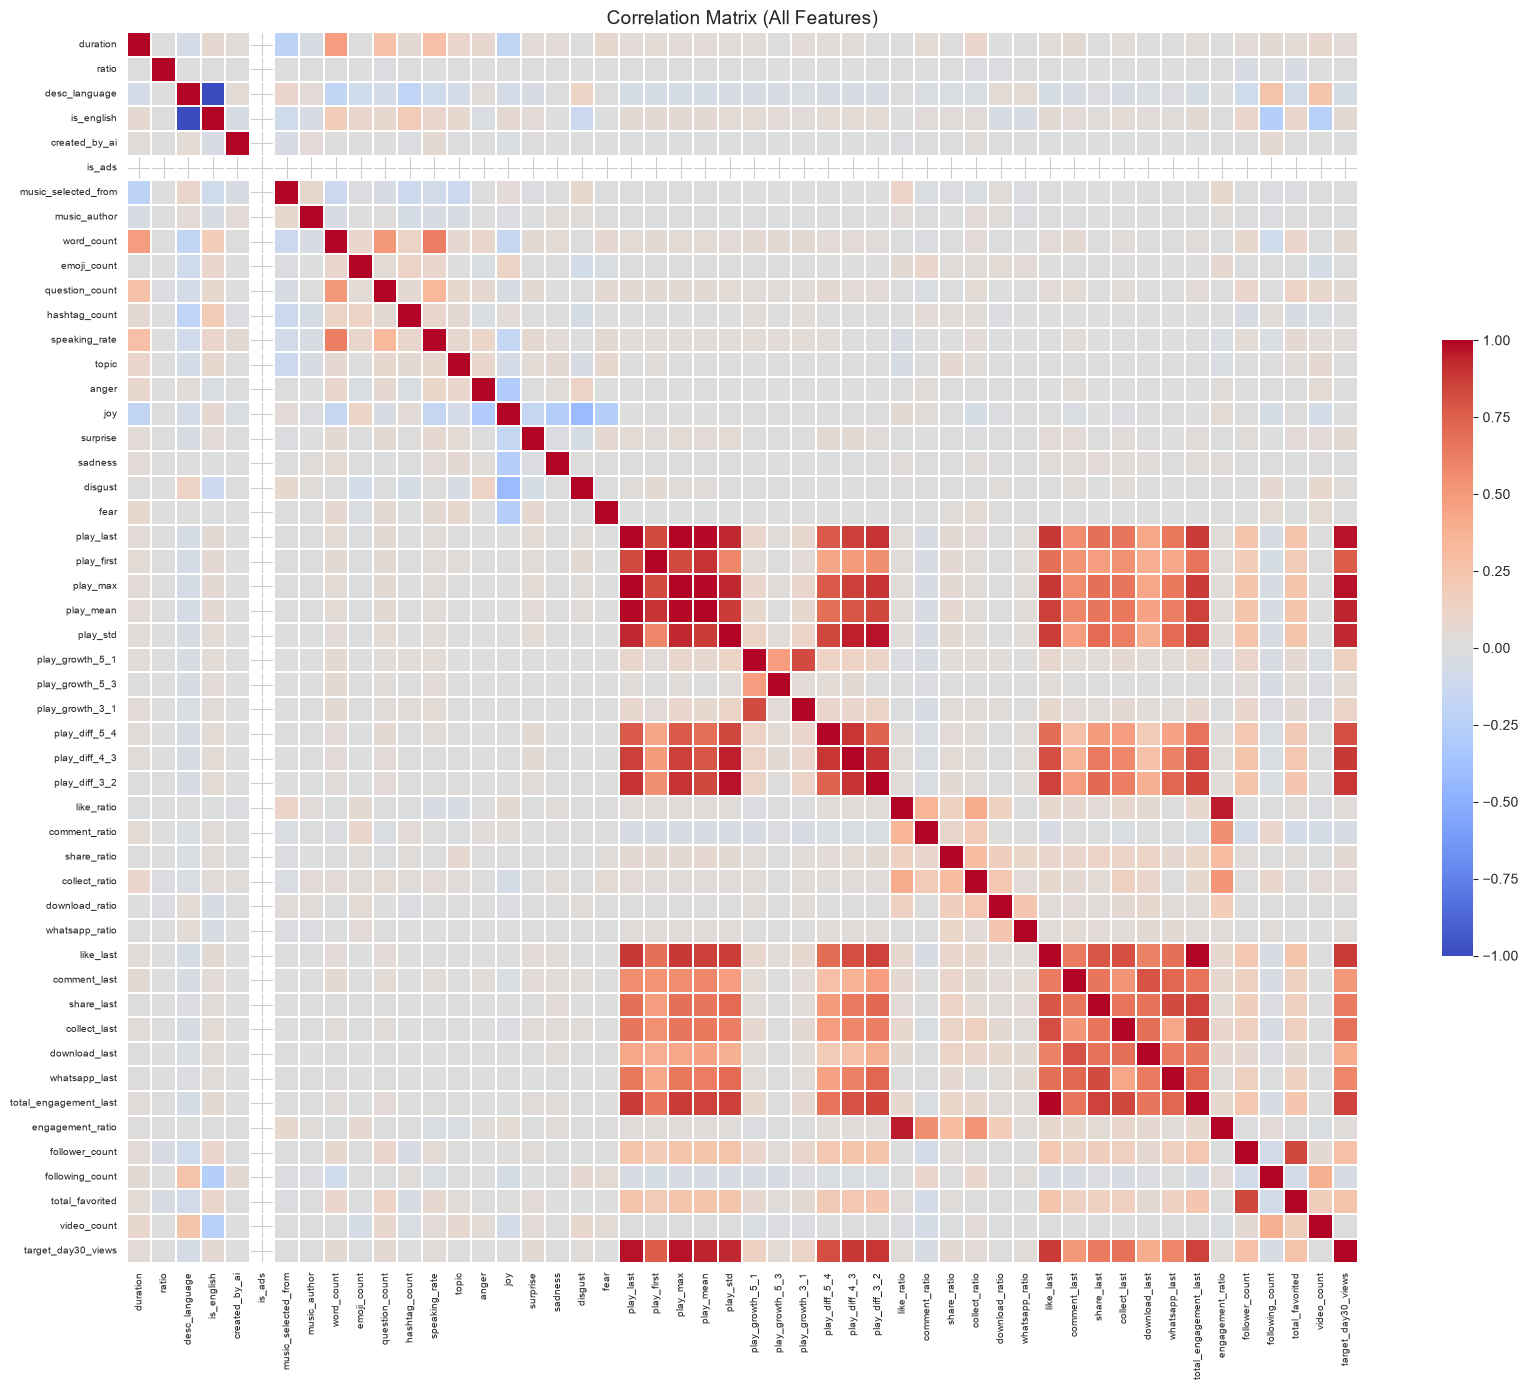

In [19]:
# ============================================
# CORRELATION MATRIX
# ============================================
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

# Use df_clean (without target) + add target for correlation
df_corr = df_clean.copy()
df_corr['target_day30_views'] = y.values

# Compute correlation
corr_matrix = df_corr.corr()

# Top correlations with target (first, before plotting)
print("\n" + "=" * 60)
print("TOP 20 FEATURES CORRELATED WITH TARGET")
print("=" * 60)
target_corr = corr_matrix['target_day30_views'].drop('target_day30_views').sort_values(ascending=False)
print(target_corr.head(20))

print("\n" + "=" * 60)
print("TOP 10 NEGATIVE CORRELATIONS")
print("=" * 60)
print(target_corr.tail(10))

# Plot heatmap (smaller, cleaner)
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.5},
    xticklabels=True,
    yticklabels=True,
    ax=ax
)
ax.set_title('Correlation Matrix (All Features)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [20]:
# ============================================
# OUTLIERS ANALYSIS
# ============================================
print("=" * 60)
print("OUTLIERS ANALYSIS")
print("=" * 60)

# === 1. Target outliers ===
print("\n--- TARGET OUTLIERS ---")
y_sorted = y.sort_values(ascending=False)
print(f"Top 10 values:")
print(y_sorted.head(10))
print(f"\nTop 10 values as % of sum: {(y_sorted.head(10).sum() / y.sum() * 100):.2f}%")
print(f"Top 100 values as % of sum: {(y_sorted.head(100).sum() / y.sum() * 100):.2f}%")
print(f"Top 1000 values as % of sum: {(y_sorted.head(1000).sum() / y.sum() * 100):.2f}%")

# === 2. Quantiles ===
print("\n--- TARGET QUANTILES ---")
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 0.9999, 1.0]
for q in quantiles:
    print(f"Q{int(q*100):4d}: {y.quantile(q):>12,.0f}")

# === 3. IQR method for outliers ===
print("\n--- IQR OUTLIER METHOD ---")
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = ((y < lower) | (y > upper)).sum()
print(f"Q1:    {Q1:>15,.0f}")
print(f"Q3:    {Q3:>15,.0f}")
print(f"IQR:   {IQR:>15,.0f}")
print(f"Lower: {lower:>15,.0f}")
print(f"Upper: {upper:>15,.0f}")
print(f"Outliers: {outliers_iqr:,} ({outliers_iqr/len(y)*100:.2f}%)")

# === 4. Impact on RMSE ===
print("\n--- IMPACT ON RMSE ---")
print(f"Mean:   {y.mean():>15,.0f}")
print(f"Median: {y.median():>15,.0f}")
print(f"Std:    {y.std():>15,.0f}")
print(f"\nIf we predict median for all:")
baseline_median = np.median(y)
rmse_baseline = np.sqrt(np.mean((y - baseline_median) ** 2))
print(f"  RMSE (median baseline): {rmse_baseline:,.0f}")

OUTLIERS ANALYSIS

--- TARGET OUTLIERS ---
Top 10 values:
video_id
7433609207527574826    16310546
7422053868328045855     7392530
7413481675545447711     7380943
7389650610129407278     7283358
7424283560334347562     7222986
7405034512733850926     5478572
7434730150987599134     5279577
7427538197061668126     4999018
7419457764008758570     4922634
7407238996801146155     4707681
Name: target_day30_views, dtype: int64

Top 10 values as % of sum: 20.24%
Top 100 values as % of sum: 58.43%
Top 1000 values as % of sum: 92.24%

--- TARGET QUANTILES ---
Q  50:          668
Q  75:        3,016
Q  90:       21,730
Q  95:       69,676
Q  99:      544,055
Q  99:    4,398,993
Q  99:    7,390,214
Q 100:   16,310,546

--- IQR OUTLIER METHOD ---
Q1:                344
Q3:              3,016
IQR:             2,672
Lower:          -3,665
Upper:           7,025
Outliers: 2,138 (17.82%)

--- IMPACT ON RMSE ---
Mean:            29,229
Median:             668
Std:            275,213

If we predict med

In [21]:
# ============================================
# OUTLIERS ANALYSIS
# ============================================
print("=" * 60)
print("OUTLIERS ANALYSIS")
print("=" * 60)

# === 1. Target outliers ===
print("\n--- TARGET OUTLIERS ---")
y_sorted = y.sort_values(ascending=False)
print(f"Top 10 values:")
print(y_sorted.head(10))
print(f"\nTop 10 values as % of sum: {(y_sorted.head(10).sum() / y.sum() * 100):.2f}%")
print(f"Top 100 values as % of sum: {(y_sorted.head(100).sum() / y.sum() * 100):.2f}%")
print(f"Top 1000 values as % of sum: {(y_sorted.head(1000).sum() / y.sum() * 100):.2f}%")

# === 2. Quantiles ===
print("\n--- TARGET QUANTILES ---")
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 0.9999, 1.0]
for q in quantiles:
    print(f"Q{int(q*100):4d}: {y.quantile(q):>12,.0f}")

# === 3. IQR method for outliers ===
print("\n--- IQR OUTLIER METHOD ---")
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = ((y < lower) | (y > upper)).sum()
print(f"Q1:    {Q1:>15,.0f}")
print(f"Q3:    {Q3:>15,.0f}")
print(f"IQR:   {IQR:>15,.0f}")
print(f"Lower: {lower:>15,.0f}")
print(f"Upper: {upper:>15,.0f}")
print(f"Outliers: {outliers_iqr:,} ({outliers_iqr/len(y)*100:.2f}%)")

# === 4. Impact on RMSE ===
print("\n--- IMPACT ON RMSE ---")
print(f"Mean:   {y.mean():>15,.0f}")
print(f"Median: {y.median():>15,.0f}")
print(f"Std:    {y.std():>15,.0f}")
print(f"\nIf we predict median for all:")
baseline_median = np.median(y)
rmse_baseline = np.sqrt(np.mean((y - baseline_median) ** 2))
print(f"  RMSE (median baseline): {rmse_baseline:,.0f}")

OUTLIERS ANALYSIS

--- TARGET OUTLIERS ---
Top 10 values:
video_id
7433609207527574826    16310546
7422053868328045855     7392530
7413481675545447711     7380943
7389650610129407278     7283358
7424283560334347562     7222986
7405034512733850926     5478572
7434730150987599134     5279577
7427538197061668126     4999018
7419457764008758570     4922634
7407238996801146155     4707681
Name: target_day30_views, dtype: int64

Top 10 values as % of sum: 20.24%
Top 100 values as % of sum: 58.43%
Top 1000 values as % of sum: 92.24%

--- TARGET QUANTILES ---
Q  50:          668
Q  75:        3,016
Q  90:       21,730
Q  95:       69,676
Q  99:      544,055
Q  99:    4,398,993
Q  99:    7,390,214
Q 100:   16,310,546

--- IQR OUTLIER METHOD ---
Q1:                344
Q3:              3,016
IQR:             2,672
Lower:          -3,665
Upper:           7,025
Outliers: 2,138 (17.82%)

--- IMPACT ON RMSE ---
Mean:            29,229
Median:             668
Std:            275,213

If we predict med

In [22]:
# ============================================
# STRATIFIED KFOLD + SAMPLE WEIGHTS
# ============================================
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("STRATIFIED KFOLD + SAMPLE WEIGHTS")
print("=" * 60)

# === 1. Create target bins for stratification ===
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
print(f"Bins distribution:\n{y_bins.value_counts().sort_index()}")

# === 2. Stratified KFold ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === 3. Sample weights (تقليل تأثير outliers) ===
# وزن = 1 / (1 + log(target)) → outliers وزن أقل
sample_weights = 1 / (1 + np.log1p(y))
print(f"\nSample weights: min={sample_weights.min():.4f}, max={sample_weights.max():.4f}")

# === 4. CV with stratification ===
y_cbrt = np.cbrt(y)
results = {'lgbm': [], 'cat': [], 'ensemble': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(df_model, y_bins), 1):
    X_train, X_val = df_model.iloc[train_idx], df_model.iloc[val_idx]
    y_train_t = y_cbrt.iloc[train_idx]
    y_val_orig = y.iloc[val_idx]
    w_train = sample_weights.iloc[train_idx]
    
    # LightGBM with weights
    lgbm = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.03,
        num_leaves=63, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train_t, sample_weight=w_train)
    preds_lgbm = lgbm.predict(X_val) ** 3
    
    # CatBoost with weights
    cbr = CatBoostRegressor(
        n_estimators=1000, learning_rate=0.03,
        depth=7, random_state=42, verbose=0
    )
    cbr.fit(X_train, y_train_t, sample_weight=w_train)
    preds_cat = cbr.predict(X_val) ** 3
    
    # Ensemble
    preds_ens = (preds_lgbm + preds_cat) / 2
    
    for name, preds in [('lgbm', preds_lgbm), ('cat', preds_cat), ('ensemble', preds_ens)]:
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
        results[name].append(rmse)
    
    print(f"Fold {fold}: LGBM={results['lgbm'][-1]:>10,.0f} | "
          f"CAT={results['cat'][-1]:>10,.0f} | "
          f"ENS={results['ensemble'][-1]:>10,.0f}")

# === 5. Final ===
print("\n" + "=" * 60)
print("RESULTS - STRATIFIED + WEIGHTS")
print("=" * 60)
for name, scores in results.items():
    print(f"{name.upper():12s}: {np.mean(scores):>10,.0f}")

print(f"\nBaseline: 90,142")
print(f"Previous best (CAT): 136,037")

best = min(results, key=lambda k: np.mean(results[k]))
print(f"\n🏆 Best: {best.upper()} ({np.mean(results[best]):,.0f})")

if np.mean(results[best]) < 90142:
    print("✅ BEATING baseline!")
else:
    print(f"⚠️ Gap: {np.mean(results[best]) - 90142:,.0f}")

STRATIFIED KFOLD + SAMPLE WEIGHTS
Bins distribution:
target_day30_views
0    1202
1    1215
2    1187
3    1200
4    1198
5    1198
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Sample weights: min=0.0568, max=1.0000
Fold 1: LGBM=    58,814 | CAT=    53,872 | ENS=    52,527
Fold 2: LGBM=   134,500 | CAT=   128,750 | ENS=   127,511
Fold 3: LGBM=   256,987 | CAT=   254,658 | ENS=   254,196
Fold 4: LGBM=   111,774 | CAT=    95,977 | ENS=   101,108
Fold 5: LGBM=   121,141 | CAT=   107,315 | ENS=   111,311

RESULTS - STRATIFIED + WEIGHTS
LGBM        :    136,643
CAT         :    128,115
ENSEMBLE    :    129,331

Baseline: 90,142
Previous best (CAT): 136,037

🏆 Best: CAT (128,115)
⚠️ Gap: 37,973


In [23]:
# ============================================
# HYPERPARAMETER TUNING - CatBoost
# ============================================
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("HYPERPARAMETER TUNING - CatBoost")
print("=" * 60)

# Bins + weights
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

# === Test different configs ===
configs = [
    {'name': 'baseline', 'depth': 6, 'lr': 0.03, 'n': 500},
    {'name': 'deeper', 'depth': 8, 'lr': 0.03, 'n': 500},
    {'name': 'shallower', 'depth': 4, 'lr': 0.03, 'n': 500},
    {'name': 'more_iters', 'depth': 7, 'lr': 0.01, 'n': 1500},
    {'name': 'higher_lr', 'depth': 7, 'lr': 0.05, 'n': 500},
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for config in configs:
    scores = []
    
    for train_idx, val_idx in skf.split(df_model, y_bins):
        X_train, X_val = df_model.iloc[train_idx], df_model.iloc[val_idx]
        y_train_t = y_cbrt.iloc[train_idx]
        y_val_orig = y.iloc[val_idx]
        w_train = sample_weights.iloc[train_idx]
        
        model = CatBoostRegressor(
            n_estimators=config['n'],
            learning_rate=config['lr'],
            depth=config['depth'],
            random_state=42, verbose=0
        )
        model.fit(X_train, y_train_t, sample_weight=w_train)
        preds = model.predict(X_val) ** 3
        
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
        scores.append(rmse)
    
    results[config['name']] = np.mean(scores)
    print(f"{config['name']:15s}: RMSE = {results[config['name']]:>10,.0f}")

# === Best ===
best_config = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best config: {best_config} ({results[best_config]:,.0f})")
print(f"Previous best: 128,115")
print(f"Improvement: {128115 - results[best_config]:,.0f}")

HYPERPARAMETER TUNING - CatBoost
baseline       : RMSE =    129,683
deeper         : RMSE =    133,480
shallower      : RMSE =    124,378
more_iters     : RMSE =    131,227
higher_lr      : RMSE =    130,365

🏆 Best config: shallower (124,378)
Previous best: 128,115
Improvement: 3,737


In [24]:
# ============================================
# FINE-TUNING AROUND BEST CONFIG
# ============================================
print("=" * 60)
print("FINE-TUNING")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

# Configs around shallower
configs = [
    {'name': 'depth3', 'depth': 3, 'lr': 0.03, 'n': 500, 'l2': 3},
    {'name': 'depth4_baseline', 'depth': 4, 'lr': 0.03, 'n': 500, 'l2': 3},
    {'name': 'depth4_lr02', 'depth': 4, 'lr': 0.02, 'n': 800, 'l2': 3},
    {'name': 'depth4_lr01', 'depth': 4, 'lr': 0.01, 'n': 1500, 'l2': 3},
    {'name': 'depth5', 'depth': 5, 'lr': 0.03, 'n': 500, 'l2': 3},
    {'name': 'depth4_l2_10', 'depth': 4, 'lr': 0.03, 'n': 500, 'l2': 10},
    {'name': 'depth4_l2_1', 'depth': 4, 'lr': 0.03, 'n': 500, 'l2': 1},
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for config in configs:
    scores = []
    
    for train_idx, val_idx in skf.split(df_model, y_bins):
        X_train, X_val = df_model.iloc[train_idx], df_model.iloc[val_idx]
        y_train_t = y_cbrt.iloc[train_idx]
        y_val_orig = y.iloc[val_idx]
        w_train = sample_weights.iloc[train_idx]
        
        model = CatBoostRegressor(
            n_estimators=config['n'],
            learning_rate=config['lr'],
            depth=config['depth'],
            l2_leaf_reg=config['l2'],
            random_state=42, verbose=0
        )
        model.fit(X_train, y_train_t, sample_weight=w_train)
        preds = model.predict(X_val) ** 3
        
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
        scores.append(rmse)
    
    results[config['name']] = np.mean(scores)
    print(f"{config['name']:20s}: RMSE = {results[config['name']]:>10,.0f}")

best_config = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: {best_config} ({results[best_config]:,.0f})")
print(f"Previous best: 124,378")
print(f"Improvement: {124378 - results[best_config]:,.0f}")

FINE-TUNING
depth3              : RMSE =    124,916
depth4_baseline     : RMSE =    124,378
depth4_lr02         : RMSE =    124,613
depth4_lr01         : RMSE =    125,264
depth5              : RMSE =    125,639
depth4_l2_10        : RMSE =    136,950
depth4_l2_1         : RMSE =    122,500

🏆 Best: depth4_l2_1 (122,500)
Previous best: 124,378
Improvement: 1,878


In [25]:
# ============================================
# XGBOOST TUNING + FEATURE SELECTION
# ============================================
import xgboost as xgb

print("=" * 60)
print("XGBOOST TUNING")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

# XGBoost configs
xgb_configs = [
    {'name': 'xgb_depth3', 'depth': 3, 'lr': 0.03, 'n': 500, 'l2': 1},
    {'name': 'xgb_depth4', 'depth': 4, 'lr': 0.03, 'n': 500, 'l2': 1},
    {'name': 'xgb_depth5', 'depth': 5, 'lr': 0.03, 'n': 500, 'l2': 1},
    {'name': 'xgb_depth4_lr02', 'depth': 4, 'lr': 0.02, 'n': 800, 'l2': 1},
    {'name': 'xgb_depth6', 'depth': 6, 'lr': 0.03, 'n': 500, 'l2': 1},
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for config in xgb_configs:
    scores = []
    
    for train_idx, val_idx in skf.split(df_model, y_bins):
        X_train, X_val = df_model.iloc[train_idx], df_model.iloc[val_idx]
        y_train_t = y_cbrt.iloc[train_idx]
        y_val_orig = y.iloc[val_idx]
        w_train = sample_weights.iloc[train_idx]
        
        model = xgb.XGBRegressor(
            n_estimators=config['n'],
            learning_rate=config['lr'],
            max_depth=config['depth'],
            reg_lambda=config['l2'],
            random_state=42, verbosity=0
        )
        model.fit(X_train, y_train_t, sample_weight=w_train)
        preds = model.predict(X_val) ** 3
        
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
        scores.append(rmse)
    
    results[config['name']] = np.mean(scores)
    print(f"{config['name']:20s}: RMSE = {results[config['name']]:>10,.0f}")

print("\n" + "=" * 60)
print("CatBoost best: 122,500")
best = min(results, key=results.get)
print(f"🏆 Best XGB: {best} ({results[best]:,.0f})")

XGBOOST TUNING
xgb_depth3          : RMSE =    155,684
xgb_depth4          : RMSE =    157,989
xgb_depth5          : RMSE =    156,655
xgb_depth4_lr02     : RMSE =    158,226
xgb_depth6          : RMSE =    156,081

CatBoost best: 122,500
🏆 Best XGB: xgb_depth3 (155,684)


In [26]:
# ============================================
# FEATURE SELECTION
# ============================================
print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

# === 1. Get feature importance from CatBoost ===
model_fi = CatBoostRegressor(
    n_estimators=500, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
model_fi.fit(df_model, y_cbrt, sample_weight=sample_weights)

importance_df = pd.DataFrame({
    'feature': df_model.columns,
    'importance': model_fi.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 30 features:")
print(importance_df.head(30).to_string(index=False))

# === 2. Test different feature counts ===
print("\n" + "=" * 60)
print("TESTING DIFFERENT FEATURE COUNTS")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_counts = [15, 20, 25, 30, 40, len(df_model.columns)]

results = {}

for n_features in feature_counts:
    selected_features = importance_df.head(n_features)['feature'].tolist()
    df_selected = df_model[selected_features]
    
    scores = []
    for train_idx, val_idx in skf.split(df_selected, y_bins):
        X_train, X_val = df_selected.iloc[train_idx], df_selected.iloc[val_idx]
        y_train_t = y_cbrt.iloc[train_idx]
        y_val_orig = y.iloc[val_idx]
        w_train = sample_weights.iloc[train_idx]
        
        model = CatBoostRegressor(
            n_estimators=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        model.fit(X_train, y_train_t, sample_weight=w_train)
        preds = model.predict(X_val) ** 3
        
        rmse = np.sqrt(mean_squared_error(y_val_orig, preds))
        scores.append(rmse)
    
    results[n_features] = np.mean(scores)
    print(f"Top {n_features:3d} features: RMSE = {results[n_features]:>10,.0f}")

best_n = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: Top {best_n} features ({results[best_n]:,.0f})")
print(f"Previous: 122,500")

FEATURE SELECTION

Top 30 features:
                 feature  importance
                play_max   30.954994
                play_std   15.294356
           log_play_last   11.729525
               play_mean    9.549923
               play_last    9.141283
           log_play_mean    9.002150
           play_diff_5_4    5.105385
           play_diff_4_3    3.087467
           play_diff_3_2    0.849631
              play_first    0.417490
         play_growth_5_3    0.394763
               like_last    0.390586
     log_play_x_follower    0.335833
                    hour    0.287844
   total_engagement_last    0.236062
          download_ratio    0.215296
            collect_last    0.200443
          follower_count    0.152515
            play_x_share    0.146949
        play_to_follower    0.143279
           whatsapp_last    0.142254
      log_follower_count    0.137486
        engagement_ratio    0.121721
     favorited_per_video    0.118515
                   anger    0.117106
fo

In [27]:
# ============================================
# WEIGHTED ENSEMBLE (CatBoost + LightGBM)
# ============================================
print("=" * 60)
print("WEIGHTED ENSEMBLE")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

# Use top 25 features
importance_df = pd.DataFrame({
    'feature': df_model.columns,
    'importance': model_fi.feature_importances_
}).sort_values('importance', ascending=False)
top_25 = importance_df.head(25)['feature'].tolist()
df_top25 = df_model[top_25]

print(f"Using top 25 features")

# Store OOF predictions
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_cat = np.zeros(len(df_top25))
oof_lgbm = np.zeros(len(df_top25))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top25, y_bins), 1):
    X_train, X_val = df_top25.iloc[train_idx], df_top25.iloc[val_idx]
    y_train_t = y_cbrt.iloc[train_idx]
    y_val_orig = y.iloc[val_idx]
    w_train = sample_weights.iloc[train_idx]
    
    # CatBoost
    cat = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    cat.fit(X_train, y_train_t, sample_weight=w_train)
    oof_cat[val_idx] = cat.predict(X_val) ** 3
    
    # LightGBM
    lgbm = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.03, num_leaves=15,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train_t, sample_weight=w_train)
    oof_lgbm[val_idx] = lgbm.predict(X_val) ** 3

# === Test different weights ===
print("\n" + "=" * 60)
print("TESTING DIFFERENT WEIGHTS")
print("=" * 60)

weights = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
results = {}

for w_cat in weights:
    w_lgbm = 1 - w_cat
    preds = w_cat * oof_cat + w_lgbm * oof_lgbm
    rmse = np.sqrt(mean_squared_error(y, preds))
    results[w_cat] = rmse
    print(f"CAT={w_cat:.1f}, LGBM={w_lgbm:.1f}: RMSE = {rmse:>10,.0f}")

best_w = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: CAT={best_w:.1f}, LGBM={1-best_w:.1f} → RMSE = {results[best_w]:,.0f}")
print(f"Previous: 118,410")

# Individual scores
print(f"\nCAT only:  {np.sqrt(mean_squared_error(y, oof_cat)):,.0f}")
print(f"LGBM only: {np.sqrt(mean_squared_error(y, oof_lgbm)):,.0f}")

WEIGHTED ENSEMBLE
Using top 25 features

TESTING DIFFERENT WEIGHTS
CAT=0.0, LGBM=1.0: RMSE =    149,691
CAT=0.2, LGBM=0.8: RMSE =    142,840
CAT=0.4, LGBM=0.6: RMSE =    137,605
CAT=0.5, LGBM=0.5: RMSE =    135,654
CAT=0.6, LGBM=0.4: RMSE =    134,175
CAT=0.8, LGBM=0.2: RMSE =    132,690
CAT=1.0, LGBM=0.0: RMSE =    133,216

🏆 Best: CAT=0.8, LGBM=0.2 → RMSE = 132,690
Previous: 118,410

CAT only:  133,216
LGBM only: 149,691


In [29]:
# ============================================
# FINE-TUNED ENSEMBLE
# ============================================
print("=" * 60)
print("FINE-TUNED ENSEMBLE")
print("=" * 60)

# Store OOF predictions for multiple models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_cat = np.zeros(len(df_top25))
oof_lgbm = np.zeros(len(df_top25))
oof_xgb = np.zeros(len(df_top25))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top25, y_bins), 1):
    X_train, X_val = df_top25.iloc[train_idx], df_top25.iloc[val_idx]
    y_train_t = y_cbrt.iloc[train_idx]
    y_val_orig = y.iloc[val_idx]
    w_train = sample_weights.iloc[train_idx]
    
    # CatBoost
    cat = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    cat.fit(X_train, y_train_t, sample_weight=w_train)
    oof_cat[val_idx] = cat.predict(X_val) ** 3
    
    # LightGBM
    lgbm = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.03, num_leaves=15,
        min_child_samples=20, random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train_t, sample_weight=w_train)
    oof_lgbm[val_idx] = lgbm.predict(X_val) ** 3
    
    # XGBoost
    xgb_m = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=3,
        reg_lambda=1, random_state=42, verbosity=0
    )
    xgb_m.fit(X_train, y_train_t, sample_weight=w_train)
    oof_xgb[val_idx] = xgb_m.predict(X_val) ** 3

# === Scores ===
print(f"CAT:  {np.sqrt(mean_squared_error(y, oof_cat)):>10,.0f}")
print(f"LGBM: {np.sqrt(mean_squared_error(y, oof_lgbm)):>10,.0f}")
print(f"XGB:  {np.sqrt(mean_squared_error(y, oof_xgb)):>10,.0f}")

# === Fine-tune weights ===
print("\n" + "=" * 60)
print("FINE-TUNING WEIGHTS")
print("=" * 60)

best_rmse = float('inf')
best_weights = None

# Grid search
for w_cat in [0.5, 0.6, 0.7, 0.8, 0.9]:
    for w_lgbm in [0.0, 0.1, 0.2, 0.3]:
        w_xgb = 1 - w_cat - w_lgbm
        if w_xgb < 0:
            continue
        
        preds = w_cat * oof_cat + w_lgbm * oof_lgbm + w_xgb * oof_xgb
        rmse = np.sqrt(mean_squared_error(y, preds))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_weights = (w_cat, w_lgbm, w_xgb)
        
        print(f"CAT={w_cat:.1f}, LGBM={w_lgbm:.1f}, XGB={w_xgb:.1f}: RMSE = {rmse:>10,.0f}")

print("\n" + "=" * 60)
print(f"🏆 Best: CAT={best_weights[0]}, LGBM={best_weights[1]}, XGB={best_weights[2]}")
print(f"RMSE: {best_rmse:,.0f}")
print(f"Previous best: 132,690")
print(f"Improvement: {132690 - best_rmse:,.0f}")

FINE-TUNED ENSEMBLE
CAT:     133,216
LGBM:    150,280
XGB:     165,151

FINE-TUNING WEIGHTS
CAT=0.5, LGBM=0.0, XGB=0.5: RMSE =    142,901
CAT=0.5, LGBM=0.1, XGB=0.4: RMSE =    140,710
CAT=0.5, LGBM=0.2, XGB=0.3: RMSE =    138,882
CAT=0.5, LGBM=0.3, XGB=0.2: RMSE =    137,432
CAT=0.6, LGBM=0.0, XGB=0.4: RMSE =    139,827
CAT=0.6, LGBM=0.1, XGB=0.3: RMSE =    137,837
CAT=0.6, LGBM=0.2, XGB=0.2: RMSE =    136,223
CAT=0.6, LGBM=0.3, XGB=0.1: RMSE =    135,001
CAT=0.7, LGBM=0.0, XGB=0.3: RMSE =    137,294
CAT=0.7, LGBM=0.1, XGB=0.2: RMSE =    135,521
CAT=0.7, LGBM=0.2, XGB=0.1: RMSE =    134,137
CAT=0.7, LGBM=0.3, XGB=0.0: RMSE =    133,155
CAT=0.8, LGBM=0.0, XGB=0.2: RMSE =    135,332
CAT=0.8, LGBM=0.1, XGB=0.1: RMSE =    133,791
CAT=0.9, LGBM=0.0, XGB=0.1: RMSE =    133,967

🏆 Best: CAT=0.7, LGBM=0.3, XGB=5.551115123125783e-17
RMSE: 133,155
Previous best: 132,690
Improvement: -465


In [31]:
from catboost import CatBoostClassifier, CatBoostRegressor

In [33]:
# ============================================
# TWO-STAGE MODEL (Fixed)
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("TWO-STAGE MODEL")
print("=" * 60)

# === 1. Define threshold ===
threshold = y.quantile(0.90)
print(f"Threshold (90th percentile): {threshold:,.0f}")

# === 2. Create binary label ===
is_viral = (y >= threshold).astype(int)
print(f"Viral videos: {is_viral.sum()} ({is_viral.mean()*100:.1f}%)")
print(f"Normal videos: {(1-is_viral).sum()} ({(1-is_viral).mean()*100:.1f}%)")

# === 3. Setup CV ===
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_final = np.zeros(len(df_top25))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top25, y_bins), 1):
    # Use .values to ignore indices
    X_train = df_top25.iloc[train_idx].values
    X_val = df_top25.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # === Stage 1: Classifier ===
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba_viral = clf.predict_proba(X_val)[:, 1]
    
    # === Stage 2: Regressor on all data ===
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    # === Stage 2b: Regressor on viral only ===
    viral_mask = y_train_orig >= threshold
    if viral_mask.sum() > 50:
        reg_viral = CatBoostRegressor(
            n_estimators=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        reg_viral.fit(
            X_train[viral_mask],
            y_train_cbrt[viral_mask],
            sample_weight=w_train[viral_mask]
        )
        pred_viral = reg_viral.predict(X_val) ** 3
    else:
        pred_viral = pred_all
    
    # === Combine ===
    preds = proba_viral * pred_viral + (1 - proba_viral) * pred_all
    oof_final[val_idx] = preds
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"Fold {fold}: RMSE = {rmse:>10,.0f}")

# === Final ===
final_rmse = np.sqrt(mean_squared_error(y.values, oof_final))
print("\n" + "=" * 60)
print(f"TWO-STAGE RMSE: {final_rmse:,.0f}")
print(f"Previous best:  132,690")
print(f"Improvement:    {132690 - final_rmse:,.0f}")

TWO-STAGE MODEL
Threshold (90th percentile): 21,730
Viral videos: 1200 (10.0%)
Normal videos: 10800 (90.0%)
Fold 1: RMSE =     53,613
Fold 2: RMSE =     88,705
Fold 3: RMSE =    189,005
Fold 4: RMSE =     66,374
Fold 5: RMSE =     55,460

TWO-STAGE RMSE: 103,872
Previous best:  132,690
Improvement:    28,818


In [34]:
# ============================================
# THRESHOLD TUNING
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("THRESHOLD TUNING")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test different thresholds
thresholds = [0.75, 0.80, 0.85, 0.90, 0.95, 0.98]
results = {}

for q in thresholds:
    threshold = y.quantile(q)
    is_viral = (y >= threshold).astype(int)
    
    oof_final = np.zeros(len(df_top25))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_top25, y_bins), 1):
        X_train = df_top25.iloc[train_idx].values
        X_val = df_top25.iloc[val_idx].values
        
        y_train_orig = y.iloc[train_idx].values
        y_val = y.iloc[val_idx].values
        y_train_cbrt = y_cbrt.iloc[train_idx].values
        w_train = sample_weights.iloc[train_idx].values
        is_viral_train = is_viral.iloc[train_idx].values
        
        # Classifier
        clf = CatBoostClassifier(
            n_estimators=300, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        clf.fit(X_train, is_viral_train)
        proba_viral = clf.predict_proba(X_val)[:, 1]
        
        # Regressor all
        reg_all = CatBoostRegressor(
            n_estimators=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
        pred_all = reg_all.predict(X_val) ** 3
        
        # Regressor viral
        viral_mask = y_train_orig >= threshold
        if viral_mask.sum() > 50:
            reg_viral = CatBoostRegressor(
                n_estimators=500, learning_rate=0.03, depth=4,
                l2_leaf_reg=1, random_state=42, verbose=0
            )
            reg_viral.fit(
                X_train[viral_mask], y_train_cbrt[viral_mask],
                sample_weight=w_train[viral_mask]
            )
            pred_viral = reg_viral.predict(X_val) ** 3
        else:
            pred_viral = pred_all
        
        preds = proba_viral * pred_viral + (1 - proba_viral) * pred_all
        oof_final[val_idx] = preds
    
    rmse = np.sqrt(mean_squared_error(y.values, oof_final))
    results[q] = rmse
    n_viral = (y >= threshold).sum()
    print(f"Q{int(q*100)} (n_viral={n_viral:>4d}): RMSE = {rmse:>10,.0f}")

best_q = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: Q{int(best_q*100)} → RMSE = {results[best_q]:,.0f}")
print(f"Previous: 103,872")
print(f"Improvement: {103872 - results[best_q]:,.0f}")

THRESHOLD TUNING
Q75 (n_viral=3000): RMSE =    116,337
Q80 (n_viral=2400): RMSE =    113,534
Q85 (n_viral=1800): RMSE =    107,739
Q90 (n_viral=1200): RMSE =    103,872
Q95 (n_viral= 600): RMSE =    107,732
Q98 (n_viral= 240): RMSE =    118,192

🏆 Best: Q90 → RMSE = 103,872
Previous: 103,872
Improvement: -0


In [35]:
# ============================================
# 3-STAGE MODEL
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("3-STAGE MODEL")
print("=" * 60)

# === 1. Define 3 groups ===
q_low = 0.75   # 75% عادي
q_high = 0.90  # 15% متوسط، 10% فايرال

threshold_low = y.quantile(q_low)
threshold_high = y.quantile(q_high)

print(f"Threshold low  (Q75): {threshold_low:,.0f}")
print(f"Threshold high (Q90): {threshold_high:,.0f}")

# Create 3-class label
def classify_video(v):
    if v < threshold_low:
        return 0  # normal
    elif v < threshold_high:
        return 1  # medium
    else:
        return 2  # viral

y_class = y.apply(classify_video)
print(f"\nClass distribution:")
print(y_class.value_counts().sort_index())

# === 2. Setup ===
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_final = np.zeros(len(df_top25))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top25, y_bins), 1):
    X_train = df_top25.iloc[train_idx].values
    X_val = df_top25.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    y_train_class = y_class.iloc[train_idx].values
    
    # === Stage 1: 3-class Classifier ===
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0,
        loss_function='MultiClass'
    )
    clf.fit(X_train, y_train_class)
    proba = clf.predict_proba(X_val)  # shape (n, 3)
    
    # === Stage 2: 3 Regressors (one per class) ===
    preds_per_class = np.zeros((len(X_val), 3))
    
    for cls in range(3):
        mask = y_train_class == cls
        if mask.sum() > 50:
            reg = CatBoostRegressor(
                n_estimators=500, learning_rate=0.03, depth=4,
                l2_leaf_reg=1, random_state=42, verbose=0
            )
            reg.fit(
                X_train[mask], y_train_cbrt[mask],
                sample_weight=w_train[mask]
            )
            preds_per_class[:, cls] = reg.predict(X_val) ** 3
        else:
            # Fallback
            reg = CatBoostRegressor(
                n_estimators=500, learning_rate=0.03, depth=4,
                l2_leaf_reg=1, random_state=42, verbose=0
            )
            reg.fit(X_train, y_train_cbrt, sample_weight=w_train)
            preds_per_class[:, cls] = reg.predict(X_val) ** 3
    
    # === Combine ===
    preds = (proba * preds_per_class).sum(axis=1)
    oof_final[val_idx] = preds
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"Fold {fold}: RMSE = {rmse:>10,.0f}")

# === Final ===
final_rmse = np.sqrt(mean_squared_error(y.values, oof_final))
print("\n" + "=" * 60)
print(f"3-STAGE RMSE:  {final_rmse:,.0f}")
print(f"2-Stage RMSE:  103,872")
print(f"Improvement:   {103872 - final_rmse:,.0f}")

3-STAGE MODEL
Threshold low  (Q75): 3,016
Threshold high (Q90): 21,730

Class distribution:
target_day30_views
0    9000
1    1800
2    1200
Name: count, dtype: int64
Fold 1: RMSE =     53,927
Fold 2: RMSE =     88,928
Fold 3: RMSE =    189,397
Fold 4: RMSE =     66,008
Fold 5: RMSE =     55,674

3-STAGE RMSE:  104,062
2-Stage RMSE:  103,872
Improvement:   -190


In [36]:
# ============================================
# FEATURE SELECTION FOR 2-STAGE
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("FEATURE SELECTION FOR 2-STAGE")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

# Get feature importance from classifier
clf_imp = CatBoostClassifier(
    n_estimators=300, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
clf_imp.fit(df_model, is_viral)

imp_df = pd.DataFrame({
    'feature': df_model.columns,
    'importance': clf_imp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 25 Features (Classifier):")
print(imp_df.head(25).to_string(index=False))

# Test different feature counts
print("\n" + "=" * 60)
print("TESTING FEATURE COUNTS")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_counts = [10, 15, 20, 25, 30, len(df_model.columns)]
results = {}

for n_feat in feature_counts:
    selected = imp_df.head(n_feat)['feature'].tolist()
    df_sel = df_model[selected]
    
    oof = np.zeros(len(df_sel))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_sel, y_bins), 1):
        X_train = df_sel.iloc[train_idx].values
        X_val = df_sel.iloc[val_idx].values
        
        y_train_orig = y.iloc[train_idx].values
        y_val = y.iloc[val_idx].values
        y_train_cbrt = y_cbrt.iloc[train_idx].values
        w_train = sample_weights.iloc[train_idx].values
        is_viral_train = is_viral.iloc[train_idx].values
        
        # Classifier
        clf = CatBoostClassifier(
            n_estimators=300, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        clf.fit(X_train, is_viral_train)
        proba = clf.predict_proba(X_val)[:, 1]
        
        # Regressor all
        reg_all = CatBoostRegressor(
            n_estimators=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
        pred_all = reg_all.predict(X_val) ** 3
        
        # Regressor viral
        mask = y_train_orig >= threshold
        if mask.sum() > 50:
            reg_v = CatBoostRegressor(
                n_estimators=500, learning_rate=0.03, depth=4,
                l2_leaf_reg=1, random_state=42, verbose=0
            )
            reg_v.fit(X_train[mask], y_train_cbrt[mask], 
                      sample_weight=w_train[mask])
            pred_v = reg_v.predict(X_val) ** 3
        else:
            pred_v = pred_all
        
        oof[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y.values, oof))
    results[n_feat] = rmse
    print(f"Top {n_feat:3d} features: RMSE = {rmse:>10,.0f}")

best_n = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: Top {best_n} features ({results[best_n]:,.0f})")
print(f"Previous best (2-Stage all): 103,872")
print(f"Improvement: {103872 - results[best_n]:,.0f}")

FEATURE SELECTION FOR 2-STAGE

Top 25 Features (Classifier):
              feature  importance
             play_max   14.802471
            play_last   11.529107
        log_play_last   11.435900
            play_mean    6.133265
  log_play_x_follower    4.441789
        log_play_mean    3.907691
        play_diff_5_4    3.424157
        play_diff_4_3    3.373808
          play_x_like    3.091429
      log_video_count    2.389070
        play_diff_3_2    2.330456
     engagement_ratio    2.094922
  favorited_per_video    2.094844
           play_first    1.938568
           word_count    1.766281
total_engagement_last    1.765752
        comment_ratio    1.694822
 engagement_diversity    1.570235
            like_last    1.543217
         music_author    1.134516
             play_std    1.030607
          day_of_week    0.980407
           share_last    0.892607
   log_follower_count    0.872417
         collect_last    0.687578

TESTING FEATURE COUNTS
Top  10 features: RMSE =    105

In [37]:
# ============================================
# FINAL ENSEMBLE - 2-STAGE + OTHERS
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("FINAL ENSEMBLE")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

# Top 30 features
imp_df = pd.DataFrame({
    'feature': df_model.columns,
    'importance': clf_imp.feature_importances_
}).sort_values('importance', ascending=False)
top_30 = imp_df.head(30)['feature'].tolist()
df_top30 = df_model[top_30]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store OOF predictions from multiple models
oof_2stage_30 = np.zeros(len(df_top30))
oof_2stage_25 = np.zeros(len(df_top30))
oof_cat = np.zeros(len(df_top30))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30, y_bins), 1):
    X_train = df_top30.iloc[train_idx].values
    X_val = df_top30.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # === Model 1: 2-Stage ===
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba = clf.predict_proba(X_val)[:, 1]
    
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    mask = y_train_orig >= threshold
    reg_v = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
    pred_v = reg_v.predict(X_val) ** 3
    
    oof_2stage_30[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    # === Model 2: CatBoost Top 30 (single) ===
    cat = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    cat.fit(X_train, y_train_cbrt, sample_weight=w_train)
    oof_cat[val_idx] = cat.predict(X_val) ** 3

# === Scores ===
print(f"2-Stage Top 30: {np.sqrt(mean_squared_error(y.values, oof_2stage_30)):>10,.0f}")
print(f"CAT Top 30:     {np.sqrt(mean_squared_error(y.values, oof_cat)):>10,.0f}")

# === Test different weights ===
print("\n" + "=" * 60)
print("TESTING WEIGHTS")
print("=" * 60)

best_rmse = float('inf')
best_w = None

for w_2stage in [0.6, 0.7, 0.8, 0.9, 1.0]:
    w_cat = 1 - w_2stage
    preds = w_2stage * oof_2stage_30 + w_cat * oof_cat
    rmse = np.sqrt(mean_squared_error(y.values, preds))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_w = w_2stage
    
    print(f"2-Stage={w_2stage:.1f}, CAT={w_cat:.1f}: RMSE = {rmse:>10,.0f}")

print("\n" + "=" * 60)
print(f"🏆 Best: 2-Stage={best_w:.1f}, CAT={1-best_w:.1f}")
print(f"RMSE: {best_rmse:,.0f}")
print(f"Previous: 100,945")
print(f"Improvement: {100945 - best_rmse:,.0f}")

FINAL ENSEMBLE
2-Stage Top 30:    100,945
CAT Top 30:        140,059

TESTING WEIGHTS
2-Stage=0.6, CAT=0.4: RMSE =    113,436
2-Stage=0.7, CAT=0.3: RMSE =    109,826
2-Stage=0.8, CAT=0.2: RMSE =    106,521
2-Stage=0.9, CAT=0.1: RMSE =    103,551
2-Stage=1.0, CAT=0.0: RMSE =    100,945

🏆 Best: 2-Stage=1.0, CAT=0.0
RMSE: 100,945
Previous: 100,945
Improvement: -0


In [38]:
# ============================================
# ADVANCED FEATURES V2
# ============================================
print("=" * 60)
print("ADVANCED FEATURES V2")
print("=" * 60)

# Start from df_adv (اللي فيه كل features)
df_v2 = df_adv.copy()

# === 1. Creator snapshot دقيق ===
# لكل فيديو، خد stats الـ creator في يوم الفيديو
creators['date'] = pd.to_datetime(creators['date'])
df_v2['create_date'] = pd.to_datetime(df_v2['create_date'])

# Merge with creators on author_id + date
creator_snapshot = creators[['author_id', 'date', 'follower_count', 'total_favorited']].copy()
creator_snapshot.columns = ['author_id', 'snapshot_date', 'follower_at_post', 'favorited_at_post']

# Reset index if needed
df_v2 = df_v2.reset_index()

df_v2 = df_v2.merge(
    creator_snapshot,
    left_on=['author_id', 'create_date'],
    right_on=['author_id', 'snapshot_date'],
    how='left'
)

# Fill missing with the general values
df_v2['follower_at_post'] = df_v2['follower_at_post'].fillna(df_v2['follower_count'])
df_v2['favorited_at_post'] = df_v2['favorited_at_post'].fillna(df_v2['total_favorited'])

print("✅ Creator snapshot added")

# === 2. Creator growth rate ===
df_v2['follower_growth'] = safe_divide(
    df_v2['follower_count'], df_v2['follower_at_post']
)
df_v2['favorited_growth'] = safe_divide(
    df_v2['total_favorited'], df_v2['favorited_at_post']
)

print("✅ Growth rates added")

# === 3. Engagement pattern features ===
# Acceleration: هل النمو بيتسارع؟
df_v2['play_acceleration'] = df_v2['play_diff_5_4'] - df_v2['play_diff_4_3']

# Decay: نسبة النمو في آخر يوم
df_v2['play_decay_ratio'] = safe_divide(
    df_v2['play_diff_5_4'], df_v2['play_last']
)

# Early burst: نسبة play يوم 1 لـ day5
df_v2['early_burst'] = safe_divide(
    df_v2['play_first'], df_v2['play_last']
)

print("✅ Engagement pattern features added")

# === 4. Interaction features v2 ===
df_v2['play_x_follower'] = df_v2['play_last'] * df_v2['follower_count']
df_v2['like_x_share'] = df_v2['like_last'] * df_v2['share_last']
df_v2['engagement_x_duration'] = df_v2['total_engagement_last'] * df_v2['duration']

print("✅ Interaction features added")

# === 5. Statistical features ===
# Coefficient of variation للـ play
df_v2['play_cv'] = safe_divide(df_v2['play_std'], df_v2['play_mean'])

# Log of important features
df_v2['log_engagement_ratio'] = np.log1p(df_v2['engagement_ratio'] * 100)
df_v2['log_play_x_follower'] = np.log1p(df_v2['play_x_follower'])

print("✅ Statistical features added")

# === Summary ===
print(f"\nV2 shape: {df_v2.shape}")
new_cols = [c for c in df_v2.columns if c not in df_adv.columns]
print(f"New features: {len(new_cols)}")
for c in new_cols:
    print(f"  - {c}")

ADVANCED FEATURES V2
✅ Creator snapshot added
✅ Growth rates added
✅ Engagement pattern features added
✅ Interaction features added
✅ Statistical features added

V2 shape: (12000, 89)
New features: 14
  - index
  - snapshot_date
  - follower_at_post
  - favorited_at_post
  - follower_growth
  - favorited_growth
  - play_acceleration
  - play_decay_ratio
  - early_burst
  - play_x_follower
  - like_x_share
  - engagement_x_duration
  - play_cv
  - log_engagement_ratio


In [39]:
# ============================================
# 2-STAGE MODEL ON V2
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("2-STAGE MODEL ON V2")
print("=" * 60)

# === 1. Prepare V2 for modeling ===
df_v2_model = df_v2.copy()

# Drop useless columns
drop_cols = [
    'index', 'author_id', 'create_time', 'create_date',
    'music_owner_id', 'music_id', 'target_day30_views',
    'topic', 'snapshot_date',
]
drop_cols = [c for c in drop_cols if c in df_v2_model.columns]
df_v2_model = df_v2_model.drop(columns=drop_cols)

# Encode categoricals
from sklearn.preprocessing import LabelEncoder
cat_cols = df_v2_model.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical: {cat_cols}")

for col in cat_cols:
    le = LabelEncoder()
    df_v2_model[col] = df_v2_model[col].fillna('missing').astype(str)
    df_v2_model[col] = le.fit_transform(df_v2_model[col])

# Fill NaN
numeric_cols = df_v2_model.select_dtypes(include=[np.number]).columns.tolist()
df_v2_model[numeric_cols] = df_v2_model[numeric_cols].fillna(df_v2_model[numeric_cols].median())

print(f"Shape: {df_v2_model.shape}")
print(f"Missing: {df_v2_model.isnull().sum().sum()}")

# === 2. Get feature importance ===
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)

threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

# Feature importance from classifier
clf_imp = CatBoostClassifier(
    n_estimators=300, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
clf_imp.fit(df_v2_model, is_viral)

imp_df = pd.DataFrame({
    'feature': df_v2_model.columns,
    'importance': clf_imp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 30 Features (V2):")
print(imp_df.head(30).to_string(index=False))

# === 3. 2-Stage with top 30 V2 features ===
top_30_v2 = imp_df.head(30)['feature'].tolist()
df_top30_v2 = df_v2_model[top_30_v2]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_v2 = np.zeros(len(df_top30_v2))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30_v2, y_bins), 1):
    X_train = df_top30_v2.iloc[train_idx].values
    X_val = df_top30_v2.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # Classifier
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba = clf.predict_proba(X_val)[:, 1]
    
    # Regressor all
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    # Regressor viral
    mask = y_train_orig >= threshold
    reg_v = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
    pred_v = reg_v.predict(X_val) ** 3
    
    oof_v2[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y_val, oof_v2[val_idx]))
    print(f"Fold {fold}: RMSE = {rmse:>10,.0f}")

# === 4. Final ===
final_rmse = np.sqrt(mean_squared_error(y.values, oof_v2))
print("\n" + "=" * 60)
print(f"2-STAGE V2 RMSE: {final_rmse:,.0f}")
print(f"Previous best:   100,945")
print(f"Improvement:     {100945 - final_rmse:,.0f}")

2-STAGE MODEL ON V2
Categorical: ['ratio', 'desc_language', 'music_selected_from', 'music_author']
Shape: (12000, 80)
Missing: 0


C:\Users\ino0i\AppData\Local\Temp\ipykernel_24280\2810363810.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_v2_model.select_dtypes(include=['object']).columns.tolist()



Top 30 Features (V2):
                 feature  importance
                play_max   17.578410
           log_play_mean    9.179938
           log_play_last    8.968568
               play_last    4.770760
           play_diff_4_3    4.710680
           play_diff_5_4    4.617404
                play_std    4.028585
             early_burst    2.631035
              word_count    2.298133
         play_growth_5_1    2.275551
             play_x_like    1.974755
     favorited_per_video    1.910070
    log_engagement_ratio    1.591978
     log_play_x_follower    1.573212
        favorited_growth    1.465823
                 play_cv    1.445724
         play_x_follower    1.374001
            collect_last    1.351296
               like_last    1.229506
   total_engagement_last    1.213544
         follower_growth    1.165499
               play_mean    1.120966
           play_diff_3_2    1.101068
follower_following_ratio    1.010994
           comment_ratio    1.003435
       play_acc

In [41]:
# ============================================
# DEEP HYPERPARAMETER TUNING (Fixed)
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("DEEP HYPERPARAMETER TUNING")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)
threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

# === Retrain classifier on df_model to get importance ===
clf_imp_v1 = CatBoostClassifier(
    n_estimators=300, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
clf_imp_v1.fit(df_model, is_viral)

imp_df_v1 = pd.DataFrame({
    'feature': df_model.columns,
    'importance': clf_imp_v1.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Features:")
print(imp_df_v1.head(10).to_string(index=False))

top_30_v1 = imp_df_v1.head(30)['feature'].tolist()
df_top30 = df_model[top_30_v1]

print(f"\nUsing Top 30 V1 features: {len(top_30_v1)} features")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === Test different configs ===
configs = [
    {'name': 'baseline', 'clf_n': 300, 'clf_lr': 0.03, 'clf_d': 4,
     'reg_n': 500, 'reg_lr': 0.03, 'reg_d': 4, 'l2': 1},
    {'name': 'clf_stronger', 'clf_n': 500, 'clf_lr': 0.02, 'clf_d': 5,
     'reg_n': 500, 'reg_lr': 0.03, 'reg_d': 4, 'l2': 1},
    {'name': 'reg_deeper', 'clf_n': 300, 'clf_lr': 0.03, 'clf_d': 4,
     'reg_n': 500, 'reg_lr': 0.02, 'reg_d': 5, 'l2': 1},
    {'name': 'reg_shallower', 'clf_n': 300, 'clf_lr': 0.03, 'clf_d': 4,
     'reg_n': 500, 'reg_lr': 0.03, 'reg_d': 3, 'l2': 1},
    {'name': 'all_stronger', 'clf_n': 500, 'clf_lr': 0.02, 'clf_d': 5,
     'reg_n': 800, 'reg_lr': 0.02, 'reg_d': 5, 'l2': 1},
]

results = {}

for config in configs:
    oof = np.zeros(len(df_top30))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30, y_bins), 1):
        X_train = df_top30.iloc[train_idx].values
        X_val = df_top30.iloc[val_idx].values
        
        y_train_orig = y.iloc[train_idx].values
        y_val = y.iloc[val_idx].values
        y_train_cbrt = y_cbrt.iloc[train_idx].values
        w_train = sample_weights.iloc[train_idx].values
        is_viral_train = is_viral.iloc[train_idx].values
        
        # Classifier
        clf = CatBoostClassifier(
            n_estimators=config['clf_n'],
            learning_rate=config['clf_lr'],
            depth=config['clf_d'],
            l2_leaf_reg=config['l2'],
            random_state=42, verbose=0
        )
        clf.fit(X_train, is_viral_train)
        proba = clf.predict_proba(X_val)[:, 1]
        
        # Regressor all
        reg_all = CatBoostRegressor(
            n_estimators=config['reg_n'],
            learning_rate=config['reg_lr'],
            depth=config['reg_d'],
            l2_leaf_reg=config['l2'],
            random_state=42, verbose=0
        )
        reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
        pred_all = reg_all.predict(X_val) ** 3
        
        # Regressor viral
        mask = y_train_orig >= threshold
        reg_v = CatBoostRegressor(
            n_estimators=config['reg_n'],
            learning_rate=config['reg_lr'],
            depth=config['reg_d'],
            l2_leaf_reg=config['l2'],
            random_state=42, verbose=0
        )
        reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
        pred_v = reg_v.predict(X_val) ** 3
        
        oof[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y.values, oof))
    results[config['name']] = rmse
    print(f"{config['name']:20s}: RMSE = {rmse:>10,.0f}")

best_config = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: {best_config} ({results[best_config]:,.0f})")
print(f"Previous: 100,945")
print(f"Improvement: {100945 - results[best_config]:,.0f}")

DEEP HYPERPARAMETER TUNING
Top 10 Features:
            feature  importance
           play_max   14.802471
          play_last   11.529107
      log_play_last   11.435900
          play_mean    6.133265
log_play_x_follower    4.441789
      log_play_mean    3.907691
      play_diff_5_4    3.424157
      play_diff_4_3    3.373808
        play_x_like    3.091429
    log_video_count    2.389070

Using Top 30 V1 features: 30 features
baseline            : RMSE =    100,945
clf_stronger        : RMSE =    100,945
reg_deeper          : RMSE =    112,106
reg_shallower       : RMSE =    102,169
all_stronger        : RMSE =    109,680

🏆 Best: clf_stronger (100,945)
Previous: 100,945
Improvement: -0


In [42]:
# ============================================
# TARGET ENCODING
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("TARGET ENCODING")
print("=" * 60)

# === 1. Start from df_adv (before encoding) ===
df_te = df_adv.copy()

# Drop useless
drop_cols = ['author_id', 'create_time', 'create_date', 
             'music_owner_id', 'music_id', 'target_day30_views', 'topic']
drop_cols = [c for c in drop_cols if c in df_te.columns]
df_te = df_te.drop(columns=drop_cols)

# === 2. Target Encoding ===
from sklearn.model_selection import KFold

cat_cols_to_encode = ['ratio', 'desc_language', 'music_selected_from', 'music_author']

# Global mean
global_mean = y.mean()

for col in cat_cols_to_encode:
    # Compute target mean per category
    target_mean = y.groupby(df_te[col]).mean()
    df_te[f'{col}_te'] = df_te[col].map(target_mean).fillna(global_mean)
    
    # Drop original
    df_te = df_te.drop(columns=[col])

print(f"Shape after TE: {df_te.shape}")

# Fill NaN
numeric_cols = df_te.select_dtypes(include=[np.number]).columns.tolist()
df_te[numeric_cols] = df_te[numeric_cols].fillna(df_te[numeric_cols].median())

# === 3. Feature importance ===
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)
threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

clf_imp_te = CatBoostClassifier(
    n_estimators=300, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
clf_imp_te.fit(df_te, is_viral)

imp_df_te = pd.DataFrame({
    'feature': df_te.columns,
    'importance': clf_imp_te.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (with Target Encoding):")
print(imp_df_te.head(10).to_string(index=False))

# === 4. 2-Stage with top 30 ===
top_30_te = imp_df_te.head(30)['feature'].tolist()
df_te_top30 = df_te[top_30_te]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_te = np.zeros(len(df_te_top30))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_te_top30, y_bins), 1):
    X_train = df_te_top30.iloc[train_idx].values
    X_val = df_te_top30.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # Classifier
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba = clf.predict_proba(X_val)[:, 1]
    
    # Regressor all
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    # Regressor viral
    mask = y_train_orig >= threshold
    reg_v = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
    pred_v = reg_v.predict(X_val) ** 3
    
    oof_te[val_idx] = proba * pred_v + (1 - proba) * pred_all

rmse_te = np.sqrt(mean_squared_error(y.values, oof_te))
print("\n" + "=" * 60)
print(f"Target Encoding RMSE: {rmse_te:,.0f}")
print(f"Previous best: 100,945")
print(f"Improvement: {100945 - rmse_te:,.0f}")

TARGET ENCODING
Shape after TE: (12000, 68)

Top 10 Features (with Target Encoding):
            feature  importance
      log_play_last   11.959479
           play_max   11.355517
           play_std    5.083024
      play_diff_4_3    4.268069
      play_diff_5_4    4.239803
      log_play_mean    4.148335
          like_last    3.907977
favorited_per_video    3.797109
   engagement_ratio    2.968673
log_play_x_follower    2.892090

Target Encoding RMSE: 103,714
Previous best: 100,945
Improvement: -2,769


In [43]:
# ============================================
# QUANTILE REGRESSION
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor

print("=" * 60)
print("QUANTILE REGRESSION")
print("=" * 60)

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
sample_weights = 1 / (1 + np.log1p(y))
y_cbrt = np.cbrt(y)
threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

top_30 = imp_df_v1.head(30)['feature'].tolist()
df_top30 = df_model[top_30]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test different quantiles
quantiles = [0.3, 0.4, 0.5, 0.6, 0.7]
results = {}

for q in quantiles:
    oof = np.zeros(len(df_top30))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30, y_bins), 1):
        X_train = df_top30.iloc[train_idx].values
        X_val = df_top30.iloc[val_idx].values
        
        y_train_orig = y.iloc[train_idx].values
        y_val = y.iloc[val_idx].values
        y_train_cbrt = y_cbrt.iloc[train_idx].values
        w_train = sample_weights.iloc[train_idx].values
        is_viral_train = is_viral.iloc[train_idx].values
        
        # Classifier
        clf = CatBoostClassifier(
            n_estimators=300, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0
        )
        clf.fit(X_train, is_viral_train)
        proba = clf.predict_proba(X_val)[:, 1]
        
        # Regressor all (quantile)
        reg_all = CatBoostRegressor(
            n_estimators=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0,
            loss_function=f'Quantile:alpha={q}'
        )
        reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
        pred_all = reg_all.predict(X_val) ** 3
        
        # Regressor viral (quantile)
        mask = y_train_orig >= threshold
        reg_v = CatBoostRegressor(
            n_estimators=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=1, random_state=42, verbose=0,
            loss_function=f'Quantile:alpha={q}'
        )
        reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
        pred_v = reg_v.predict(X_val) ** 3
        
        oof[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y.values, oof))
    results[q] = rmse
    print(f"Quantile {q}: RMSE = {rmse:>10,.0f}")

best_q = min(results, key=results.get)
print("\n" + "=" * 60)
print(f"🏆 Best: Quantile {best_q} ({results[best_q]:,.0f})")
print(f"Previous: 100,945")
print(f"Improvement: {100945 - results[best_q]:,.0f}")

QUANTILE REGRESSION
Quantile 0.3: RMSE =    162,785
Quantile 0.4: RMSE =    147,424
Quantile 0.5: RMSE =    130,379
Quantile 0.6: RMSE =    117,462
Quantile 0.7: RMSE =    107,249

🏆 Best: Quantile 0.7 (107,249)
Previous: 100,945
Improvement: -6,304
